# 11 - Feature Selection, Error Case Review, and Ablation Study

## Objective

Notebook này dùng để chuẩn bị bộ feature đáng tin cậy trước khi tuning model, đồng thời so sánh song song `target_price` và `log_target_price`. Trọng tâm không phải tìm metric đẹp ngay, mà là xác định:

| Area | Key Question |
|---|---|
| Error case review | Các prediction bất thường là lỗi dữ liệu, thiếu feature, hay model chưa học được pattern? |
| Feature audit | Có leakage, cột nhiễu, cột trùng lặp, high-missing hoặc high-cardinality không? |
| Multi-target baseline | So sánh `target_price` và `log_target_price` trên cùng split để tránh kết luận lệch do target transform. |
| Baseline clean retraining | Sau khi loại cột xấu, baseline có ổn hơn không? |
| Feature importance | Feature nào ảnh hưởng nhiều đến global error và segment error? |
| Group ablation | Nhóm CPU/RAM/GPU/Storage/Screen/Brand/Text có đóng góp thật không? |
| Segment-aware strategy | Có cần sample weighting hoặc xử lý riêng Low/Premium không? |

> Notebook này nên chạy sau `10_model_diagnostics_and_error_analysis.ipynb` và trước notebook tuning.

## 1. Imports and Configuration

In [301]:
from __future__ import annotations

import json
import pickle
import re
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.inspection import permutation_importance

CURRENT_DIR = Path.cwd().resolve()

# Expected case: running notebook from notebooks/modeling/
if CURRENT_DIR.name == "modeling" and CURRENT_DIR.parent.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent.parent

# Case: running from notebooks/
elif CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent

# Case: running from project root
elif (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR

# Fallback: search upward for src/
else:
    PROJECT_ROOT = None

    for path in [CURRENT_DIR] + list(CURRENT_DIR.parents):
        if (path / "src").exists():
            PROJECT_ROOT = path
            break

    if PROJECT_ROOT is None:
        raise FileNotFoundError(
            "Could not find project root containing src/ folder. "
            f"Current directory: {CURRENT_DIR}"
        )

SRC_DIR = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("CURRENT_DIR:", CURRENT_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR exists:", SRC_DIR.exists())

# Optional but recommended: make src a package
if SRC_DIR.exists():
    init_file = SRC_DIR / "__init__.py"
    init_file.touch(exist_ok=True)
    print("__init__.py exists:", init_file.exists())

try:
    from src.catboots.modeling import (
        build_catboost_model,
        make_train_test_data,
        train_catboost_model,
        inverse_prediction_to_price,
        compute_regression_metrics,
        compute_segment_metrics,
        build_prediction_frame,
        plot_true_vs_predicted,
        run_catboost_experiment
    )

    print("Imported CatBoost utilities from src.catboots successfully.")

except ModuleNotFoundError as e:
    print("\nFailed to import from src.catboots.")
    print("Available .py files in src/:")

    if SRC_DIR.exists():
        for p in sorted(SRC_DIR.glob("*.py")):
            print("-", p.name)

    raise e

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

try:
    import joblib
    HAS_JOBLIB = True
except ImportError:
    HAS_JOBLIB = False

# ------------------------------------------------------------
# 4. Display and warning config
# ------------------------------------------------------------

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

PRICE_SEGMENT_ORDER = ["Low", "Mid", "High", "Premium"]

TARGET_PRICE_COL = "target_price"
TARGET_LOG_PRICE_COL = "log_target_price"
SEGMENT_COL = "price_segment"

TARGET_COLUMNS = [TARGET_PRICE_COL, TARGET_LOG_PRICE_COL]

# Main training target: log only
PRIMARY_TARGET = TARGET_LOG_PRICE_COL
PRIMARY_MODEL_NAME = "CatBoost"

TARGET_CONFIGS = [
    {
        "name": TARGET_LOG_PRICE_COL,
        "primary_use": "Log-scale regression; use np.expm1 to invert predictions to price scale.",
        "inverse_transform": "np.expm1",
    }
]

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

DATA_PATH = DATA_DIR / "processed" / "laptop_processed_numeric.csv"

print("\nConfig ready.")
print("PRIMARY_TARGET:", PRIMARY_TARGET)
print("DATA_PATH:", DATA_PATH)
print("DATA_PATH exists:", DATA_PATH.exists())
print("HAS_JOBLIB:", HAS_JOBLIB)

CURRENT_DIR: Y:\Python\Laptop-Price-Prediction\notebooks\modeling
PROJECT_ROOT: Y:\Python\Laptop-Price-Prediction
SRC_DIR exists: True
__init__.py exists: True
Imported CatBoost utilities from src.catboots successfully.

Config ready.
PRIMARY_TARGET: log_target_price
DATA_PATH: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
DATA_PATH exists: True
HAS_JOBLIB: True


In [302]:
def find_project_root(start: Path | None = None) -> Path:
    """Find project root by looking for data/ and artifacts/ folders.
    Works whether this notebook is run from project root or notebooks/... subfolder.
    """
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / "data").exists() and (p / "artifacts").exists():
            return p
    # fallback used by previous notebook when cwd is notebooks/<subfolder>
    if len(start.parents) >= 2:
        return start.parents[1]
    return start

PROJECT_ROOT = find_project_root()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "laptop_processed_numeric.csv"
RAW_DATA_CANDIDATES = [
    PROJECT_ROOT / "data" / "processed" / "laptop_processed.csv",
    PROJECT_ROOT / "data" / "processed" / "laptop_cleaned.csv",
    PROJECT_ROOT / "data" / "raw" / "chotot_laptop_data.csv",
]

ARTIFACT_DIR     = PROJECT_ROOT / "artifacts" / "modeling_numeric"
METRICS_DIR      = ARTIFACT_DIR / "metrics"
PREDICTIONS_DIR  = ARTIFACT_DIR / "predictions"
DIAGNOSTICS_DIR  = ARTIFACT_DIR / "model_diagnostics"
FEATURE_SEL_DIR  = ARTIFACT_DIR / "feature_selection"
MODEL_DIRS       = [ARTIFACT_DIR / "models", ARTIFACT_DIR / "trained_models", ARTIFACT_DIR]

FEATURE_SEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"DATA_PATH      : {DATA_PATH}")
print(f"ARTIFACT_DIR   : {ARTIFACT_DIR}")
print(f"FEATURE_SEL_DIR: {FEATURE_SEL_DIR}")

PROJECT_ROOT   : Y:\Python\Laptop-Price-Prediction
DATA_PATH      : Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
ARTIFACT_DIR   : Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric
FEATURE_SEL_DIR: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\feature_selection


## 2. Utility Functions

In [303]:
def read_first_existing_csv(candidates, required_any_columns=None, label="CSV"):
    """Read the first existing CSV candidate. Optionally require at least one matching column."""
    for p in candidates:
        p = Path(p)
        if not p.exists():
            continue
        try:
            df = pd.read_csv(p)
            if required_any_columns is not None:
                has_any = any(c in df.columns for c in required_any_columns)
                if not has_any:
                    continue
            print(f"Loaded {label}: {p.name}  shape={df.shape}")
            return df, p
        except Exception as e:
            print(f"Skip {p}: {e}")
    return None, None


def load_pickle_or_joblib(path: Path):
    """Load .pkl/.pickle/.joblib files if available."""
    path = Path(path)
    if not path.exists():
        return None
    if HAS_JOBLIB and path.suffix.lower() in [".joblib", ".pkl", ".pickle"]:
        try:
            return joblib.load(path)
        except Exception:
            pass
    with open(path, "rb") as f:
        return pickle.load(f)


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]
    return df


def assign_price_segment_by_quantile(y, q25=None, q50=None, q75=None):
    y = pd.Series(y).astype(float)
    if q25 is None or q50 is None or q75 is None:
        q25, q50, q75 = np.quantile(y.dropna(), [0.25, 0.50, 0.75])
    seg = pd.cut(
        y,
        bins=[-np.inf, q25, q50, q75, np.inf],
        labels=PRICE_SEGMENT_ORDER,
        include_lowest=True,
    )
    return pd.Categorical(seg, categories=PRICE_SEGMENT_ORDER, ordered=True), (q25, q50, q75)


def compute_error_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    residual = actual - predicted
    ape = np.abs(residual) / (actual + 1e-9)
    return {
        "n": len(actual),
        "mae": mean_absolute_error(actual, predicted),
        "rmse": root_mean_squared_error(actual, predicted),
        "mape": mean_absolute_percentage_error(actual, predicted),
        "median_absolute_error": median_absolute_error(actual, predicted),
        "mean_residual": residual.mean(),
        "median_residual": np.median(residual),
        "underprediction_rate": (residual > 0).mean(),
        "overprediction_rate": (residual < 0).mean(),
        "severe_error_rate": (ape > 0.50).mean(),
        "extreme_error_rate": (ape > 1.00).mean(),
        "r2": r2_score(actual, predicted),
    }

def target_prediction_to_price(pred_target, target_name: str):
    """Convert model output back to original price scale for business metrics."""
    pred_target = np.asarray(pred_target, dtype=float)
    if target_name == "log_target_price":
        return np.expm1(pred_target)
    if target_name == "target_price":
        return pred_target
    raise ValueError(f"Unknown target_name={target_name}")


def get_target_config(target_name: str) -> dict:
    for cfg in TARGET_CONFIGS:
        if cfg["name"] == target_name:
            return cfg
    raise ValueError(f"Unknown target_name={target_name}")


def evaluate_price_scale_by_segment(actual_price, pred_price, segment, target_name=None, model_name=None):
    """Return global + segment metrics on original price scale."""
    rows = []
    base = compute_error_metrics(actual_price, pred_price)
    base.update({"scope": "global", "segment": "All"})
    rows.append(base)

    segment = pd.Series(segment).astype(str).reset_index(drop=True)
    actual_price = pd.Series(actual_price).reset_index(drop=True)
    pred_price = pd.Series(pred_price).reset_index(drop=True)

    for seg in PRICE_SEGMENT_ORDER:
        mask = segment.eq(seg)
        if mask.sum() == 0:
            continue
        m = compute_error_metrics(actual_price[mask], pred_price[mask])
        m.update({"scope": "segment", "segment": seg})
        rows.append(m)

    out = pd.DataFrame(rows)
    if target_name is not None:
        out.insert(0, "target", target_name)
    if model_name is not None:
        out.insert(0, "model", model_name)
    return out


## 3. Discover Available Artifacts

Cell này chỉ liệt kê các file đang có để tránh load nhầm artifact.

In [304]:
print("=== Processed data ===")
for p in [DATA_PATH, *RAW_DATA_CANDIDATES]:
    print(f"{p.exists()}  {p}")

print("\n=== Metrics files ===")
for f in sorted(METRICS_DIR.glob("*.csv")):
    print(" ", f.name)

print("\n=== Prediction files ===")
for f in sorted(PREDICTIONS_DIR.glob("*.csv")):
    print(" ", f.name)

print("\n=== Diagnostic files ===")
for f in sorted(DIAGNOSTICS_DIR.glob("*.csv")):
    print(" ", f.name)

print("\n=== Possible model files ===")
for d in MODEL_DIRS:
    if d.exists():
        for f in sorted(list(d.glob("*.pkl")) + list(d.glob("*.pickle")) + list(d.glob("*.joblib"))):
            print(" ", f.relative_to(PROJECT_ROOT))


=== Processed data ===
True  Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
False  Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed.csv
False  Y:\Python\Laptop-Price-Prediction\data\processed\laptop_cleaned.csv
True  Y:\Python\Laptop-Price-Prediction\data\raw\chotot_laptop_data.csv

=== Metrics files ===
  log_scale_model_metrics.csv
  model_metrics.csv

=== Prediction files ===
  test_predictions.csv

=== Diagnostic files ===
  CatBoost_log_vs_raw_compression.csv
  correction_experiment_CatBoost.csv
  correction_experiment_LightGBM.csv
  diagnostic_errors_long.csv
  diagnostic_model_error_summary.csv
  final_diagnostic_summary.csv
  heteroscedasticity_binned_error_summary.csv
  heteroscedasticity_correlation_tests.csv
  LightGBM_log_vs_raw_compression.csv
  low_price_segment_diagnostics.csv
  low_price_top_error_cases.csv
  potential_outliers_CatBoost.csv
  potential_outliers_LightGBM.csv
  premium_segment_diagnostics.csv
  premium_top_e

## 4. Load Processed Data, Metrics, Predictions, and Diagnostics

In [305]:
# Load processed numeric dataset
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Processed numeric dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Loaded processed numeric data: {df.shape}")
display(df.head())

# Tự sinh log_target_price nếu chưa có trong data
if "log_target_price" not in df.columns and "target_price" in df.columns:
    df["log_target_price"] = np.log1p(df["target_price"])
    print("[INFO] log_target_price derived from target_price via np.log1p")

missing_targets = [c for c in TARGET_COLUMNS if c not in df.columns]
if missing_targets:
    raise ValueError(f"Missing target columns in processed data: {missing_targets}")

feature_cols_all = [c for c in df.columns if c not in TARGET_COLUMNS]
numeric_feature_cols = df[feature_cols_all].select_dtypes(include=[np.number]).columns.tolist()

print(f"All feature columns    : {len(feature_cols_all)}")
print(f"Numeric feature columns: {len(numeric_feature_cols)}")

Loaded processed numeric data: (7208, 77)


,ram_gb,storage_gb,screen_size_inch,brand_is_rare,model_is_rare,ram_missing,storage_missing,screen_missing,target_price,log_target_price,no_info_brand,no_info_model,no_info_cpu_brand,no_info_cpu_tier,no_info_gpu,storage_ssd,storage_hdd,no_info_storage,condition_score,warranty_encoded,cpu_tier_encoded,brand_ASUS,brand_Acer,brand_Apple,brand_Dell,brand_Gigabyte,brand_HP,brand_LG,brand_Lenovo,brand_MSI,brand_Microsoft,brand_Other,brand_Sony,brand_Toshiba,model_Aspire,model_Elitebook,model_Elitebook 800,model_Gaming Thin GF,model_IdeaPad,model_Inspiron,model_Latitude,model_Latitude 14 7000,model_Latitude E Series,model_Legion,model_Legion 5,model_MacBook Air,model_MacBook Air M1,model_MacBook Air M2,model_MacBook Pro,model_MacBook Pro M1,model_MacBook Pro M2,model_Macbook air m4,model_Nitro 5,model_Other,model_Pavilion 15,model_Precision,model_ProBook,model_ROG Strix,model_TUF Gaming,model_TUF Gaming F15,model_ThinkPad,model_ThinkPad X1 Carbon,model_Vivobook 15,model_Vostro,model_X Series,model_XPS 13,cpu_brand_AMD,cpu_brand_Apple,cpu_brand_Intel,cpu_brand_Microsoft SQ,cpu_brand_Other,cpu_brand_Qualcomm,gpu_tier_ord_filled,gpu_type_Apple SoC,gpu_type_Dedicated,gpu_type_Integrated,gpu_type_Missing_Info
0,16.0000,256.0000,13.9500,0,0,0,0,0,9.9900,2.3970,0,0,0,0,0,1,0,0,2,1,6,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
1,8.0000,127.0000,15.9500,0,0,0,0,0,4.5000,1.7047,0,1,0,0,0,1,0,0,2,1,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
2,8.0000,512.0000,11.9500,0,0,0,0,0,3.5000,1.5041,0,1,0,0,0,1,0,0,2,1,6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
3,32.0000,512.0000,13.9500,0,0,0,0,0,37.5000,3.6507,0,1,0,1,0,1,0,0,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
4,16.0000,256.0000,13.9500,0,0,0,0,0,7.9900,2.1961,0,1,1,1,0,1,0,0,2,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0


All feature columns    : 75
Numeric feature columns: 75


In [306]:
# Optional: load raw/cleaned data for manual inspection of error cases
raw_df, raw_data_path = read_first_existing_csv(RAW_DATA_CANDIDATES, label="raw/cleaned data")
if raw_df is not None:
    print(f"Raw/cleaned data path: {raw_data_path}")
    display(raw_df.head())
else:
    print("No raw/cleaned data found. Error case review will use numeric features only.")

Loaded raw/cleaned data: chotot_laptop_data.csv  shape=(5866, 15)
Raw/cleaned data path: Y:\Python\Laptop-Price-Prediction\data\raw\chotot_laptop_data.csv


,url,price,title,Hãng,Dòng máy,Tình trạng,Chính sách bảo hành,Kích cỡ màn hình,Bộ vi xử lý,RAM,Card màn hình,Ổ cứng,Xuất xứ,Loại ổ cứng,Thông tin sử dụng
0,https://www.chotot.com/mua-ban-quan-tan-binh-t...,9.990.000 đ,Laptop 2in1 Dell 7420 I7 1185G7/16G/256G,Dell,Latitude,Đã sử dụng (chưa sửa chữa),>12 tháng,13 - 14.9 inch,Intel Core i7,16 GB,Onboard,256 GB,Mỹ,SSD,In trên bao bì
1,https://www.chotot.com/mua-ban-thanh-pho-thu-d...,4.500.000 đ,Acer Aspire A315-58 i3-1115G4,Acer,Aspire A3,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,15 - 16.9 inch,Intel Core i3,8 GB,Onboard,< 128 GB,Đang cập nhật,SSD,In trên bao bì
2,https://www.chotot.com/mua-ban-quan-ha-dong-ha...,3.500.000 đ,Thanh lý Laptop HP Elite x2 1012G1 cảm ứng 2in1,HP,Elite X2,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,11 - 12.9 inch,Intel Core i7,8 GB,Onboard,512 GB,Đang cập nhật,SSD,In trên bao bì
3,https://www.chotot.com/mua-ban-quan-7-tp-ho-ch...,37.500.000 đ,Dell Pro Rugged RB14250 Ultra 7-165U 32GB 512GB,Dell,Pro Rugged 14,Đã sử dụng (chưa sửa chữa),>12 tháng,13 - 14.9 inch,Intel Core Ultra,32 GB,Onboard,512 GB,Mỹ,SSD,In trên bao bì
4,https://www.chotot.com/mua-ban-quan-12-tp-ho-c...,7.990.000 đ,HP Spectre x360 13-ae015dx i7 cảm ứng gập 360 độ,HP,Spectre,Đã sử dụng (chưa sửa chữa),3 tháng,13 - 14.9 inch,NaN,16 GB,Onboard,256 GB,Đang cập nhật,SSD,In trên bao bì


In [307]:
# Load metrics from previous modeling notebook
metrics_candidates = [
    METRICS_DIR / "model_metrics.csv",
    METRICS_DIR / "metrics_df.csv",
    METRICS_DIR / "all_metrics.csv",
]
metrics_df, metrics_path = read_first_existing_csv(metrics_candidates, label="metrics")

if metrics_df is not None:
    metrics_df = normalize_columns(metrics_df)
    metrics_df.rename(columns={"median_ae": "median_absolute_error", "train_time_sec": "training_time_seconds"}, inplace=True)
    if "mape" in metrics_df.columns and metrics_df["mape"].max() > 10:
        metrics_df["mape"] = metrics_df["mape"] / 100.0
    display(metrics_df.head(10))
else:
    print("No metrics file found. This notebook can still run feature audit, but baseline comparison will be limited.")

Loaded metrics: model_metrics.csv  shape=(16, 12)


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_absolute_error,max_error,training_time_seconds,predict_time_sec
0,CatBoost,gradient_boosting,target_price,target_price,3.4705,5.4785,0.8653,0.3302,2.1144,36.2442,8.0484,0.0041
1,CatBoost,gradient_boosting,log_target_price,target_price,3.4455,5.6434,0.8571,0.2899,1.9306,37.5938,7.9994,0.0034
2,LightGBM,gradient_boosting,target_price,target_price,3.5269,5.7620,0.8511,0.3200,1.9498,38.6261,1.0455,0.0191
3,LightGBM,gradient_boosting,log_target_price,target_price,3.4375,5.7633,0.8510,0.2893,1.8491,38.5314,1.7507,0.0211
4,Random Forest,tree_ensemble,log_target_price,target_price,3.5388,5.8795,0.8449,0.3051,1.9392,36.1898,1.8360,0.1520
5,Random Forest,tree_ensemble,target_price,target_price,3.5747,5.8937,0.8442,0.3305,1.9434,37.3202,1.8648,0.1742
6,Extra Trees,tree_ensemble,log_target_price,target_price,3.7410,6.1857,0.8283,0.3206,2.0445,45.0000,2.1408,0.1710
7,Extra Trees,tree_ensemble,target_price,target_price,3.8199,6.2636,0.8240,0.3471,2.0825,45.0000,1.9662,0.1751
8,Ridge,linear,target_price,target_price,4.3560,6.4143,0.8154,0.4580,2.9109,50.6677,0.1689,0.0061
9,Lasso,linear,target_price,target_price,4.3555,6.4146,0.8154,0.4578,2.9154,50.7307,2.1067,0.0060


In [308]:
# Load predictions from previous modeling notebook
prediction_candidates = [
    PREDICTIONS_DIR / "test_predictions.csv",
    PREDICTIONS_DIR / "predictions_df.csv",
    PREDICTIONS_DIR / "all_predictions.csv",
]
predictions_raw, predictions_path = read_first_existing_csv(
    prediction_candidates,
    required_any_columns=["actual_price", "target_price", "y_true_price"],
    label="predictions",
)

if predictions_raw is None:
    # fallback: any CSV containing prediction columns
    for f in sorted(PREDICTIONS_DIR.glob("*.csv")):
        try:
            df_try = pd.read_csv(f)
            if any("pred" in c.lower() for c in df_try.columns):
                predictions_raw = df_try
                predictions_path = f
                print(f"Fallback predictions: {f.name}  shape={df_try.shape}")
                break
        except Exception:
            continue

if predictions_raw is not None:
    display(predictions_raw.head())
    print("Prediction columns:", [c for c in predictions_raw.columns if "pred" in c.lower()])
else:
    print("No prediction file found. Error case review from previous predictions will be skipped.")

Loaded predictions: test_predictions.csv  shape=(1442, 18)


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
0,308,9.0000,9.6641,7.5611,9.6946,7.5296,9.6908,7.6658,9.6976,7.6043,6.7468,6.2711,6.9308,6.4150,6.9120,6.5745,8.7198,6.9512
1,381,10.5000,10.6328,8.0600,10.4302,7.9252,10.4369,7.8958,10.4315,7.9140,9.0842,8.8218,9.0997,8.8671,9.1409,8.7900,8.9843,8.5053
2,1839,2.0000,4.6875,5.6674,4.6735,5.8175,4.6646,5.8844,4.6578,5.8550,2.8033,2.7044,3.1748,2.8450,3.7969,3.3711,3.8885,3.5125
3,3438,11.5000,13.9141,13.7706,13.8621,13.2717,13.8765,13.0689,13.8730,13.1694,12.8945,12.6684,12.8956,12.6720,13.4430,13.5301,13.0165,13.0666
4,251,9.2000,10.0234,8.0423,10.2500,8.1516,10.2458,8.0850,10.2675,8.1148,8.2383,7.6625,10.1611,6.7065,9.5467,9.0143,9.2180,8.5379


Prediction columns: ['pred_LinearRegression_target_price', 'pred_LinearRegression_log_target_price', 'pred_Ridge_target_price', 'pred_Ridge_log_target_price', 'pred_Lasso_target_price', 'pred_Lasso_log_target_price', 'pred_ElasticNet_target_price', 'pred_ElasticNet_log_target_price', 'pred_RandomForest_target_price', 'pred_RandomForest_log_target_price', 'pred_ExtraTrees_target_price', 'pred_ExtraTrees_log_target_price', 'pred_LightGBM_target_price', 'pred_LightGBM_log_target_price', 'pred_CatBoost_target_price', 'pred_CatBoost_log_target_price']


In [309]:
# Load diagnostic error dataset from notebook 10 if available
DIAG_LONG_PATH = DIAGNOSTICS_DIR / "diagnostic_errors_long.csv"
if DIAG_LONG_PATH.exists():
    diag_df = pd.read_csv(DIAG_LONG_PATH)
    print(f"Loaded diagnostic errors: {diag_df.shape}")
    display(diag_df.head())
else:
    diag_df = None
    print("diagnostic_errors_long.csv not found. Run notebook 10 first if you need previous error-case review.")

Loaded diagnostic errors: (5768, 12)


,sample_id,actual_price,predicted_price,model_name,target_used,residual,absolute_error,squared_error,percentage_error,absolute_percentage_error,prediction_ratio,price_segment
0,308,9.0000,6.9512,CatBoost,log_target_price,2.0488,2.0488,4.1974,0.2276,0.2276,0.7724,Mid
1,381,10.5000,8.5053,CatBoost,log_target_price,1.9947,1.9947,3.9789,0.1900,0.1900,0.8100,Mid
2,1839,2.0000,3.5125,CatBoost,log_target_price,-1.5125,1.5125,2.2877,-0.7563,0.7563,1.7563,Low
3,3438,11.5000,13.0666,CatBoost,log_target_price,-1.5666,1.5666,2.4544,-0.1362,0.1362,1.1362,High
4,251,9.2000,8.5379,CatBoost,log_target_price,0.6621,0.6621,0.4384,0.0720,0.0720,0.9280,Mid


## 5. Validate Inputs and Build Base Feature Matrix

In [310]:
validation_rows = []

def record_check(check, status, detail=""):
    validation_rows.append({"check": check, "status": status, "detail": detail})
    icon = "OK" if status == "PASS" else "WARN" if status == "WARN" else "FAIL"
    print(f"[{icon}] {check}: {detail}")

record_check("Processed dataset exists", "PASS" if DATA_PATH.exists() else "FAIL", str(DATA_PATH))
record_check("Target columns", "PASS" if not missing_targets else "FAIL", f"missing={missing_targets}")
record_check("Feature count", "PASS" if len(feature_cols_all) > 0 else "FAIL", f"n_features={len(feature_cols_all)}")
record_check("Numeric feature count", "PASS" if len(numeric_feature_cols) > 0 else "WARN", f"n_numeric={len(numeric_feature_cols)}")
record_check("Metrics loaded", "PASS" if metrics_df is not None else "WARN", str(metrics_path))
record_check("Predictions loaded", "PASS" if predictions_raw is not None else "WARN", str(predictions_path))
record_check("Diagnostics loaded", "PASS" if diag_df is not None else "WARN", str(DIAG_LONG_PATH))

validation_df = pd.DataFrame(validation_rows)
display(validation_df)
validation_df.to_csv(FEATURE_SEL_DIR / "input_validation_summary.csv", index=False)

[OK] Processed dataset exists: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
[OK] Target columns: missing=[]
[OK] Feature count: n_features=75
[OK] Numeric feature count: n_numeric=75
[OK] Metrics loaded: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\metrics\model_metrics.csv
[OK] Predictions loaded: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\predictions\test_predictions.csv
[OK] Diagnostics loaded: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\diagnostic_errors_long.csv


,check,status,detail
0,Processed dataset exists,PASS,Y:\Python\Laptop-Price-Prediction\data\process...
1,Target columns,PASS,missing=[]
2,Feature count,PASS,n_features=75
3,Numeric feature count,PASS,n_numeric=75
4,Metrics loaded,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...
5,Predictions loaded,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...
6,Diagnostics loaded,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...


In [311]:
# Build common X and per-target y objects
available_targets = [cfg["name"] for cfg in TARGET_CONFIGS if cfg["name"] in df.columns]
if not available_targets:
    raise ValueError(f"No target columns from TARGET_CONFIGS found. Expected one of: {[c['name'] for c in TARGET_CONFIGS]}")

X_all = df[feature_cols_all].copy()
y_by_target = {target: df[target].copy() for target in available_targets}
y_price = df["target_price"].copy()

price_segment, price_quantiles = assign_price_segment_by_quantile(y_price)

print("Targets used for feature selection / ablation:")
for cfg in TARGET_CONFIGS:
    status = "available" if cfg["name"] in available_targets else "missing"
    print(f"- {cfg['name']:<16s} [{status}] | {cfg['primary_use']}")

print(f"\nX_all shape: {X_all.shape}")
print(f"Price quantiles Q25/Q50/Q75: {price_quantiles}")
print(pd.Series(price_segment).value_counts().sort_index())


Targets used for feature selection / ablation:
- log_target_price [available] | Log-scale regression; use np.expm1 to invert predictions to price scale.

X_all shape: (7208, 75)
Price quantiles Q25/Q50/Q75: (5.6, 10.5, 18.9)
Low        1818
Mid        1825
High       1773
Premium    1792
Name: count, dtype: int64


## 6. Error Case Review from Previous Predictions

Mục tiêu: xem các case model predict bất thường trước khi tin vào feature importance.

Notebook sẽ xuất bảng review cho từng target nếu `diag_df` có `target_used`:

- `target_price`: tập trung absolute error và Premium underprediction.
- `log_target_price`: tập trung relative error, Low overprediction và compression ở Premium.


In [312]:
# Build error-case tables from diag_df if available, for both target_price and log_target_price
if diag_df is not None:
    required_cols = {"actual_price", "predicted_price", "residual", "absolute_percentage_error", "prediction_ratio", "price_segment"}
    missing = required_cols - set(diag_df.columns)
    if missing:
        print(f"diag_df missing columns: {missing}")
    else:
        saved_paths = []
        targets_for_review = available_targets if "target_used" in diag_df.columns else [PRIMARY_TARGET]

        for target_name in targets_for_review:
            review_df = diag_df.copy()
            suffix = target_name

            if {"model_name", "target_used"}.issubset(review_df.columns):
                mask = (review_df["model_name"].eq(PRIMARY_MODEL_NAME)) & (review_df["target_used"].eq(target_name))
                if mask.any():
                    review_df = review_df[mask].copy()
                    print(f"Using pair for review: {PRIMARY_MODEL_NAME} + {target_name} | n={len(review_df)}")
                else:
                    print(f"Pair not found in diag_df: {PRIMARY_MODEL_NAME} + {target_name}; skip this target.")
                    continue
            elif "target_used" in review_df.columns:
                review_df = review_df[review_df["target_used"].eq(target_name)].copy()
                print(f"Using target for review: {target_name} | n={len(review_df)}")

            if len(review_df) == 0:
                continue

            sort_col = "absolute_error" if "absolute_error" in review_df.columns else "residual"
            top_absolute_errors = review_df.sort_values(sort_col, key=lambda s: s.abs(), ascending=False).head(50)
            top_premium_under = review_df[(review_df["price_segment"].astype(str) == "Premium") & (review_df["residual"] > 0)].sort_values("residual", ascending=False).head(50)
            top_low_over = review_df[(review_df["price_segment"].astype(str) == "Low") & (review_df["residual"] < 0)].sort_values("residual", ascending=True).head(50)
            top_percentage_errors = review_df.sort_values("absolute_percentage_error", ascending=False).head(50)

            outputs = {
                f"review_top_absolute_errors_{suffix}.csv": top_absolute_errors,
                f"review_top_premium_underprediction_{suffix}.csv": top_premium_under,
                f"review_top_low_overprediction_{suffix}.csv": top_low_over,
                f"review_top_percentage_errors_{suffix}.csv": top_percentage_errors,
            }
            for fname, table in outputs.items():
                out_path = FEATURE_SEL_DIR / fname
                table.to_csv(out_path, index=False)
                saved_paths.append(out_path)

            print(f"Saved review tables for {target_name}.")
            display(top_absolute_errors.head(10))

        print("Saved files:")
        for p in saved_paths:
            print("-", p.name)
else:
    print("Skip: diag_df not available.")


Using pair for review: CatBoost + log_target_price | n=1442
Saved review tables for log_target_price.


,sample_id,actual_price,predicted_price,model_name,target_used,residual,absolute_error,squared_error,percentage_error,absolute_percentage_error,prediction_ratio,price_segment
944,6544,73.9000,36.3062,CatBoost,log_target_price,37.5938,37.5938,"1,413.2907",0.5087,0.5087,0.4913,Premium
341,6148,60.4900,25.2651,CatBoost,log_target_price,35.2249,35.2249,"1,240.7910",0.5823,0.5823,0.4177,Premium
1106,3274,42.0000,7.5580,CatBoost,log_target_price,34.4420,34.4420,"1,186.2503",0.8200,0.8200,0.1800,Premium
1369,5721,76.5000,42.2723,CatBoost,log_target_price,34.2277,34.2277,"1,171.5330",0.4474,0.4474,0.5526,Premium
1332,5396,60.9000,33.3980,CatBoost,log_target_price,27.5020,27.5020,756.3611,0.4516,0.4516,0.5484,Premium
189,5345,62.9900,35.6912,CatBoost,log_target_price,27.2988,27.2988,745.2237,0.4334,0.4334,0.5666,Premium
1153,6970,64.3900,37.1908,CatBoost,log_target_price,27.1992,27.1992,739.7957,0.4224,0.4224,0.5776,Premium
634,6957,12.8900,39.4371,CatBoost,log_target_price,-26.5471,26.5471,704.7479,-2.0595,2.0595,3.0595,High
1298,6740,50.0489,24.6084,CatBoost,log_target_price,25.4405,25.4405,647.2206,0.5083,0.5083,0.4917,Premium
843,5767,57.2900,32.4263,CatBoost,log_target_price,24.8637,24.8637,618.2052,0.4340,0.4340,0.5660,Premium


Saved files:
- review_top_absolute_errors_log_target_price.csv
- review_top_premium_underprediction_log_target_price.csv
- review_top_low_overprediction_log_target_price.csv
- review_top_percentage_errors_log_target_price.csv


### Nhận xét

Bảng review cho thấy các lỗi dự đoán lớn nhất của CatBoost chủ yếu tập trung ở nhóm `Premium`. Với target gốc `target_price`, nhiều laptop có giá thật cao nhưng model lại dự đoán thấp hơn khá nhiều, thể hiện qua `residual > 0` và `prediction_ratio < 1`. Một số trường hợp có `prediction_ratio` rất thấp, nghĩa là giá dự đoán chỉ bằng khoảng 20–60% so với giá thực tế. Điều này cho thấy model đang có xu hướng kéo các sản phẩm giá cao về vùng giá trung bình, tức là chưa học đủ tốt các tín hiệu giúp phân biệt laptop cao cấp với các sản phẩm thông thường.

Khi chuyển sang `log_target_price`, hiện tượng underprediction ở nhóm `Premium` vẫn còn xuất hiện rõ. Log target có thể giúp giảm ảnh hưởng của các giá trị cực lớn và làm model ổn định hơn với sai số tương đối, nhưng trong bảng review này nó chưa giải quyết được vấn đề dự đoán thấp ở phân khúc giá cao. Một số case thậm chí có dự đoán thấp hơn so với mô hình train trực tiếp trên `target_price`, cho thấy log transformation có thể gây hiện tượng nén giá, làm các laptop đắt tiền bị dự đoán gần hơn về vùng giá trung bình.

Ngoài các case underprediction ở nhóm `Premium`, bảng cũng xuất hiện một vài trường hợp overprediction mạnh, khi giá thật thấp hơn nhiều so với giá dự đoán. Những dòng này có thể là các sản phẩm có đặc trưng giống laptop cao cấp nhưng giá thực tế thấp, hoặc có thể liên quan đến dữ liệu nhiễu, giá crawl sai, thiếu thông tin về tình trạng máy, bảo hành, đời máy hoặc chất lượng sản phẩm. Vì vậy, trước khi tin hoàn toàn vào feature importance, cần kiểm tra lại các dòng lỗi lớn trong dữ liệu gốc, đặc biệt là các thông tin như `title`, brand, CPU, GPU, RAM, storage, condition và source.

Nhìn chung, bảng này cho thấy lỗi của model không chỉ là sai số ngẫu nhiên mà có dấu hiệu sai lệch theo phân khúc giá. CatBoost đang gặp khó khăn ở nhóm laptop giá cao, đặc biệt là xu hướng dự đoán thấp cho các sản phẩm `Premium`. Bước tiếp theo nên là phân tích residual theo `price_segment`, kiểm tra các dòng Premium bị underpredict, so sánh đặc điểm của chúng với các dòng dự đoán đúng, và xem xét bổ sung thêm các feature liên quan đến dòng sản phẩm, đời máy, tình trạng máy, GPU, thương hiệu cao cấp hoặc thông tin từ title.

In [313]:
# Additional annotation for error cases: flag suspected issue type
if diag_df is not None and "absolute_percentage_error" in diag_df.columns:
    ape_col = "absolute_percentage_error"
    review_all = diag_df.copy()

    def flag_issue_type(row):
        ape = row.get(ape_col, 0)
        seg = str(row.get("price_segment", ""))
        residual = row.get("residual", 0)
        if ape > 1.0:
            return "extreme_error"
        elif ape > 0.5:
            return "severe_error"
        elif seg == "Premium" and residual > 0:
            return "premium_underprediction"
        elif seg == "Low" and residual < 0:
            return "low_overprediction"
        elif ape > 0.25:
            return "moderate_error"
        else:
            return "normal"

    review_all["issue_type"] = review_all.apply(flag_issue_type, axis=1)
    issue_summary = review_all["issue_type"].value_counts().reset_index()
    issue_summary.columns = ["issue_type", "count"]
    issue_summary["rate"] = issue_summary["count"] / len(review_all)
    display(issue_summary)
    issue_summary.to_csv(FEATURE_SEL_DIR / "error_case_issue_summary.csv", index=False)
    print("Saved: error_case_issue_summary.csv")
else:
    print("No diag_df or required columns; skipping issue-type annotation.")


,issue_type,count,rate
0,normal,2463,0.4270
1,moderate_error,983,0.1704
2,premium_underprediction,899,0.1559
3,low_overprediction,613,0.1063
4,severe_error,591,0.1025
5,extreme_error,219,0.0380


Saved: error_case_issue_summary.csv


### Nhận xét

Bảng review cho thấy các lỗi dự đoán lớn nhất của CatBoost chủ yếu tập trung ở nhóm `Premium`. Với target gốc `target_price`, nhiều laptop có giá thật cao nhưng model lại dự đoán thấp hơn khá nhiều, thể hiện qua `residual > 0` và `prediction_ratio < 1`. Một số trường hợp có `prediction_ratio` rất thấp, nghĩa là giá dự đoán chỉ bằng khoảng 20–60% so với giá thực tế. Điều này cho thấy model đang có xu hướng kéo các sản phẩm giá cao về vùng giá trung bình, tức là chưa học đủ tốt các tín hiệu giúp phân biệt laptop cao cấp với các sản phẩm thông thường.

Khi chuyển sang `log_target_price`, hiện tượng underprediction ở nhóm `Premium` vẫn còn xuất hiện rõ. Log target có thể giúp giảm ảnh hưởng của các giá trị cực lớn và làm model ổn định hơn với sai số tương đối, nhưng trong bảng review này nó chưa giải quyết được vấn đề dự đoán thấp ở phân khúc giá cao. Một số case thậm chí có dự đoán thấp hơn so với mô hình train trực tiếp trên `target_price`, cho thấy log transformation có thể gây hiện tượng nén giá, làm các laptop đắt tiền bị dự đoán gần hơn về vùng giá trung bình.

Ngoài các case underprediction ở nhóm `Premium`, bảng cũng xuất hiện một vài trường hợp overprediction mạnh, khi giá thật thấp hơn nhiều so với giá dự đoán. Những dòng này có thể là các sản phẩm có đặc trưng giống laptop cao cấp nhưng giá thực tế thấp, hoặc có thể liên quan đến dữ liệu nhiễu, giá crawl sai, thiếu thông tin về tình trạng máy, bảo hành, đời máy hoặc chất lượng sản phẩm. Vì vậy, trước khi tin hoàn toàn vào feature importance, cần kiểm tra lại các dòng lỗi lớn trong dữ liệu gốc, đặc biệt là các thông tin như `title`, brand, CPU, GPU, RAM, storage, condition và source.

Nhìn chung, bảng này cho thấy lỗi của model không chỉ là sai số ngẫu nhiên mà có dấu hiệu sai lệch theo phân khúc giá. CatBoost đang gặp khó khăn ở nhóm laptop giá cao, đặc biệt là xu hướng dự đoán thấp cho các sản phẩm `Premium`. Bước tiếp theo nên là phân tích residual theo `price_segment`, kiểm tra các dòng Premium bị underpredict, so sánh đặc điểm của chúng với các dòng dự đoán đúng, và xem xét bổ sung thêm các feature liên quan đến dòng sản phẩm, đời máy, tình trạng máy, GPU, thương hiệu cao cấp hoặc thông tin từ title.

## 7. Feature Inventory and Group Definition

Mục tiêu: chia feature thành nhóm để làm group ablation.

Bạn có thể chỉnh keyword mapping bên dưới nếu tên cột của bạn khác.

In [314]:
FEATURE_GROUP_KEYWORDS = {
    "brand": ["brand", "hãng", "hang", "manufacturer"],
    "cpu": ["cpu", "processor", "core", "ryzen", "intel", "chip"],
    "ram": ["ram", "memory"],
    "storage": ["storage", "ssd", "hdd", "disk", "drive", "ổ", "dung_lượng_ổ", "dung_luong_o"],
    "gpu": ["gpu", "vga", "graphics", "card"],
    "screen": ["screen", "display", "inch", "resolution", "refresh", "màn", "man_hinh"],
    "physical": ["weight", "battery", "material", "thickness", "case", "chất_liệu", "chat_lieu"],
    "connectivity": ["wifi", "bluetooth", "port", "usb", "hdmi", "webcam", "kết_nối", "ket_noi"],
    "text": ["title", "name", "keyword", "token", "text", "product_line"],
    "seller_location": ["seller", "shop", "location", "province", "district", "city", "source"],
}


def infer_feature_group(col: str) -> str:
    c = col.lower()
    for group, keywords in FEATURE_GROUP_KEYWORDS.items():
        if any(k.lower() in c for k in keywords):
            return group
    return "other"

feature_inventory = pd.DataFrame({"feature": feature_cols_all})
feature_inventory["dtype"] = [str(X_all[c].dtype) for c in feature_cols_all]
feature_inventory["missing_rate"] = [X_all[c].isna().mean() for c in feature_cols_all]
feature_inventory["n_unique"] = [X_all[c].nunique(dropna=True) for c in feature_cols_all]
feature_inventory["group"] = feature_inventory["feature"].apply(infer_feature_group)
feature_inventory["example_values"] = [X_all[c].dropna().astype(str).head(3).tolist() for c in feature_cols_all]

feature_inventory = feature_inventory.sort_values(["group", "missing_rate", "n_unique"], ascending=[True, False, False])
feature_inventory.to_csv(FEATURE_SEL_DIR / "feature_inventory.csv", index=False)

display(feature_inventory.head(30))
print(feature_inventory["group"].value_counts())

,feature,dtype,missing_rate,n_unique,group,example_values
3,brand_is_rare,int64,0.0000,2,brand,"[0, 0, 0]"
8,no_info_brand,int64,0.0000,2,brand,"[0, 0, 0]"
10,no_info_cpu_brand,int64,0.0000,2,brand,"[0, 0, 0]"
19,brand_ASUS,int64,0.0000,2,brand,"[0, 0, 0]"
20,brand_Acer,int64,0.0000,2,brand,"[0, 1, 0]"
21,brand_Apple,int64,0.0000,2,brand,"[0, 0, 0]"
22,brand_Dell,int64,0.0000,2,brand,"[1, 0, 0]"
23,brand_Gigabyte,int64,0.0000,2,brand,"[0, 0, 0]"
24,brand_HP,int64,0.0000,2,brand,"[0, 0, 1]"
25,brand_LG,int64,0.0000,2,brand,"[0, 0, 0]"


group
other      35
brand      22
gpu         6
storage     5
cpu         3
ram         2
screen      2
Name: count, dtype: int64


In [315]:
# Print feature inventory summary and missing_count
feature_inventory["missing_count"] = [int(X_all[c].isna().sum()) for c in feature_cols_all]
display(feature_inventory[["feature", "group", "dtype", "missing_count", "missing_rate", "n_unique", "example_values"]].head(40))

# Group-level summary
group_summary = (
    feature_inventory.groupby("group")
    .agg(
        n_features=("feature", "count"),
        avg_missing_rate=("missing_rate", "mean"),
        high_missing_cols=("missing_rate", lambda x: (x >= 0.5).sum()),
    )
    .reset_index()
    .sort_values("n_features", ascending=False)
)
print("\nFeature group summary:")
display(group_summary)
group_summary.to_csv(FEATURE_SEL_DIR / "feature_group_summary.csv", index=False)
print(f"Saved: feature_group_summary.csv")


,feature,group,dtype,missing_count,missing_rate,n_unique,example_values
3,brand_is_rare,brand,int64,0,0.0000,2,"[0, 0, 0]"
8,no_info_brand,brand,int64,0,0.0000,2,"[0, 0, 0]"
10,no_info_cpu_brand,brand,int64,0,0.0000,2,"[0, 0, 0]"
19,brand_ASUS,brand,int64,0,0.0000,2,"[0, 0, 0]"
20,brand_Acer,brand,int64,0,0.0000,2,"[0, 1, 0]"
21,brand_Apple,brand,int64,0,0.0000,2,"[0, 0, 0]"
22,brand_Dell,brand,int64,0,0.0000,2,"[1, 0, 0]"
23,brand_Gigabyte,brand,int64,0,0.0000,2,"[0, 0, 0]"
24,brand_HP,brand,int64,0,0.0000,2,"[0, 0, 1]"
25,brand_LG,brand,int64,0,0.0000,2,"[0, 0, 0]"



Feature group summary:


,group,n_features,avg_missing_rate,high_missing_cols
3,other,35,0.0000,0
0,brand,22,0.0000,0
2,gpu,6,0.0000,0
6,storage,5,0.0000,0
1,cpu,3,0.0000,0
4,ram,2,0.0000,0
5,screen,2,0.0000,0


Saved: feature_group_summary.csv


## 8. Leakage, Invalid Columns, and Redundancy Check

Làm bước này trước feature importance. Nếu để leakage hoặc ID-like columns vào model, importance sẽ dễ bị méo.

In [316]:
LEAKAGE_KEYWORDS = [
    "target", "price", "gia", "giá", "log_price", "raw_price", "discount", "installment", "monthly_payment",
]
ID_LIKE_KEYWORDS = [
    "id_", "url", "image", "html", "crawl", "timestamp", "created_at", "updated_at",
]

leakage_candidates = [c for c in feature_cols_all if any(k in c.lower() for k in LEAKAGE_KEYWORDS)]
id_like_candidates = [c for c in feature_cols_all if any(k in c.lower() for k in ID_LIKE_KEYWORDS)]
constant_cols = feature_inventory.loc[feature_inventory["n_unique"] <= 1, "feature"].tolist()
high_missing_cols = feature_inventory.loc[feature_inventory["missing_rate"] >= 0.90, "feature"].tolist()
high_cardinality_cols = feature_inventory.loc[
    (feature_inventory["n_unique"] > max(100, 0.5 * len(df))) & (~feature_inventory["dtype"].str.contains("int|float", case=False, regex=True)),
    "feature"
].tolist()

feature_quality_flags = pd.DataFrame({
    "category": ["leakage_candidate", "id_like_candidate", "constant", "high_missing_90", "high_cardinality_non_numeric"],
    "features": [leakage_candidates, id_like_candidates, constant_cols, high_missing_cols, high_cardinality_cols],
    "count": [len(leakage_candidates), len(id_like_candidates), len(constant_cols), len(high_missing_cols), len(high_cardinality_cols)],
})

display(feature_quality_flags)
feature_quality_flags.to_csv(FEATURE_SEL_DIR / "feature_quality_flags.csv", index=False)

initial_drop_candidates = sorted(set(leakage_candidates + id_like_candidates + constant_cols))
print(f"Initial drop candidates ({len(initial_drop_candidates)}):")
for c in initial_drop_candidates:
    print(" -", c)

,category,features,count
0,leakage_candidate,[],0
1,id_like_candidate,[],0
2,constant,[],0
3,high_missing_90,[],0
4,high_cardinality_non_numeric,[],0


Initial drop candidates (0):


IdeaPAd không liên quan đến Id ta không drop

In [317]:
# Create clean feature candidate set v0
# Review this list manually before finalizing.
MANUAL_KEEP = []
MANUAL_DROP = []

features_to_drop_v0 = sorted(set(initial_drop_candidates + MANUAL_DROP) - set(MANUAL_KEEP))
features_clean_v0 = [c for c in feature_cols_all if c not in features_to_drop_v0]

print(f"Original features: {len(feature_cols_all)}")
print(f"Drop v0          : {len(features_to_drop_v0)}")
print(f"Clean v0         : {len(features_clean_v0)}")

pd.Series(features_to_drop_v0, name="feature").to_csv(FEATURE_SEL_DIR / "features_to_drop_v0.csv", index=False)
pd.Series(features_clean_v0, name="feature").to_csv(FEATURE_SEL_DIR / "features_clean_v0.csv", index=False)

Original features: 75
Drop v0          : 0
Clean v0         : 75


## 9. High-Error Feature Audit

Mục tiêu: log ra các dòng model lỗi cao kèm feature context để tự phân tích trước khi loại feature hoặc chỉnh feature set.

Notebook sẽ lưu các artifact chính:

- `high_error_feature_snapshot_*_all_features.csv`: top error rows + toàn bộ feature ban đầu.
- `high_error_feature_snapshot_*_clean_v0_features.csv`: top error rows + feature sau leakage/ID/constant drop.
- `high_error_feature_flags_*.csv`: long table các feature bị missing, rare value hoặc extreme value trên từng dòng lỗi cao.
- `high_error_feature_contrast_*.csv`: feature nào khác biệt nhất giữa nhóm high-error và phần còn lại.
- `high_error_feature_group_summary_*.csv`: summary theo feature group để nhìn nhanh nhóm feature đáng audit.


In [318]:
# High-error feature audit: attach feature context to the worst prediction cases
HIGH_ERROR_TOP_N = 80
RARE_VALUE_MAX_RATE = 0.01
LOW_CARDINALITY_MAX_UNIQUE = 30
FEATURE_CONTRAST_TOP_N = 80


def safe_artifact_name(value: str) -> str:
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(value)).strip("_")


def select_review_frame_for_target(diag_source: pd.DataFrame, target_name: str, model_name: str = PRIMARY_MODEL_NAME) -> pd.DataFrame:
    """Return diagnostic rows for the requested model-target pair when possible."""
    review = diag_source.copy()
    if {"model_name", "target_used"}.issubset(review.columns):
        pair_mask = review["model_name"].eq(model_name) & review["target_used"].eq(target_name)
        if pair_mask.any():
            return review[pair_mask].copy()
        print(f"[WARN] Pair not found for high-error audit: {model_name} + {target_name}")
        return pd.DataFrame()
    if "target_used" in review.columns:
        return review[review["target_used"].eq(target_name)].copy()
    return review.copy()


def top_error_cases(review_df: pd.DataFrame, top_n: int = HIGH_ERROR_TOP_N) -> pd.DataFrame:
    if review_df.empty:
        return review_df.copy()
    if "absolute_error" in review_df.columns:
        return review_df.sort_values("absolute_error", ascending=False).head(top_n).copy()
    if "residual" in review_df.columns:
        return review_df.assign(_abs_residual=review_df["residual"].abs()).sort_values("_abs_residual", ascending=False).drop(columns="_abs_residual").head(top_n).copy()
    return review_df.head(top_n).copy()


def attach_feature_snapshot(error_df: pd.DataFrame, feature_cols: list[str], raw_context_cols: int = 0) -> pd.DataFrame:
    """Merge diagnostic error rows with processed features using sample_id."""
    if error_df.empty:
        return error_df.copy()

    meta_cols = [
        "sample_id", "model_name", "target_used", "actual_price", "predicted_price",
        "residual", "absolute_error", "absolute_percentage_error", "prediction_ratio", "price_segment",
        "issue_type",
    ]
    meta_cols = [c for c in meta_cols if c in error_df.columns]
    out = error_df[meta_cols].copy()

    if "sample_id" not in out.columns:
        out = out.reset_index().rename(columns={"index": "sample_id"})
        print("[WARN] diag_df has no sample_id; using diagnostic row index for snapshot alignment.")

    feature_cols = [c for c in feature_cols if c in X_all.columns]
    feature_lookup = X_all[feature_cols].reset_index().rename(columns={"index": "sample_id"})
    out = out.merge(feature_lookup, on="sample_id", how="left", validate="many_to_one")

    if raw_df is not None and "sample_id" in out.columns and raw_context_cols > 0:
        raw_lookup = raw_df.reset_index().rename(columns={"index": "sample_id"})
        raw_cols = [c for c in raw_lookup.columns if c != "sample_id"][:raw_context_cols]
        raw_lookup = raw_lookup[["sample_id", *raw_cols]].rename(columns={c: f"raw__{c}" for c in raw_cols})
        out = out.merge(raw_lookup, on="sample_id", how="left", validate="many_to_one")

    return out


def build_feature_flag_table(error_df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    """Flag feature values worth checking inside the high-error rows."""
    if error_df.empty or "sample_id" not in error_df.columns:
        return pd.DataFrame()

    feature_cols = [c for c in feature_cols if c in X_all.columns]
    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X_all[c])]
    high_ids = pd.Index(error_df["sample_id"].dropna().astype(int).unique())
    high_features = X_all.loc[X_all.index.intersection(high_ids), feature_cols].copy()
    if high_features.empty:
        return pd.DataFrame()

    quantiles = X_all[numeric_cols].quantile([0.01, 0.99]).T if numeric_cols else pd.DataFrame()
    rows = []

    low_cardinality_cols = [c for c in feature_cols if X_all[c].nunique(dropna=True) <= LOW_CARDINALITY_MAX_UNIQUE]
    value_rate_maps = {
        c: X_all[c].value_counts(dropna=False, normalize=True).to_dict()
        for c in low_cardinality_cols
    }

    error_meta_cols = [
        "sample_id", "actual_price", "predicted_price", "residual", "absolute_error",
        "absolute_percentage_error", "prediction_ratio", "price_segment", "issue_type",
    ]
    error_meta_cols = [c for c in error_meta_cols if c in error_df.columns]
    error_meta = error_df[error_meta_cols].drop_duplicates("sample_id").set_index("sample_id")

    for sample_id, values in high_features.iterrows():
        meta = error_meta.loc[sample_id].to_dict() if sample_id in error_meta.index else {}
        for feature in feature_cols:
            value = values[feature]
            flags = []
            if pd.isna(value):
                flags.append("missing")
            else:
                if feature in numeric_cols and feature in quantiles.index:
                    q01 = quantiles.loc[feature, 0.01]
                    q99 = quantiles.loc[feature, 0.99]
                    if pd.notna(q01) and pd.notna(q99):
                        if value < q01:
                            flags.append("low_extreme_value")
                        elif value > q99:
                            flags.append("high_extreme_value")
                if feature in value_rate_maps:
                    rate = value_rate_maps[feature].get(value, 0.0)
                    if rate <= RARE_VALUE_MAX_RATE:
                        flags.append("rare_value")

            for flag in flags:
                rows.append({
                    "sample_id": sample_id,
                    "feature": feature,
                    "feature_group": infer_feature_group(feature),
                    "feature_value": value,
                    "flag": flag,
                    **meta,
                })

    return pd.DataFrame(rows)


def build_high_error_feature_contrast(error_df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    """Compare high-error rows against the remaining rows for each numeric feature."""
    if error_df.empty or "sample_id" not in error_df.columns:
        return pd.DataFrame()

    feature_cols = [c for c in feature_cols if c in X_all.columns and pd.api.types.is_numeric_dtype(X_all[c])]
    if not feature_cols:
        return pd.DataFrame()

    high_ids = set(error_df["sample_id"].dropna().astype(int).tolist())
    high_mask = pd.Series(X_all.index.isin(high_ids), index=X_all.index)
    if high_mask.sum() == 0 or (~high_mask).sum() == 0:
        return pd.DataFrame()

    rows = []
    for feature in feature_cols:
        high = X_all.loc[high_mask, feature]
        rest = X_all.loc[~high_mask, feature]
        all_std = X_all[feature].std(skipna=True)
        mean_high = high.mean(skipna=True)
        mean_rest = rest.mean(skipna=True)
        std_mean_diff = np.nan if not all_std or pd.isna(all_std) else (mean_high - mean_rest) / all_std
        rows.append({
            "feature": feature,
            "feature_group": infer_feature_group(feature),
            "mean_high_error": mean_high,
            "mean_other_rows": mean_rest,
            "std_mean_diff": std_mean_diff,
            "missing_rate_high_error": high.isna().mean(),
            "missing_rate_other_rows": rest.isna().mean(),
            "missing_rate_delta": high.isna().mean() - rest.isna().mean(),
            "n_unique_high_error": high.nunique(dropna=True),
            "n_unique_other_rows": rest.nunique(dropna=True),
        })

    out = pd.DataFrame(rows)
    out["abs_std_mean_diff"] = out["std_mean_diff"].abs()
    out["abs_missing_rate_delta"] = out["missing_rate_delta"].abs()
    return out.sort_values(["abs_std_mean_diff", "abs_missing_rate_delta"], ascending=False).head(FEATURE_CONTRAST_TOP_N)


if diag_df is None:
    print("Skip high-error feature audit: diag_df not available.")
else:
    high_error_outputs = []

    for target_name in available_targets:
        review_df = select_review_frame_for_target(diag_df, target_name)
        if review_df.empty:
            continue

        if "issue_type" not in review_df.columns and "issue_type" in globals().get("review_all", pd.DataFrame()).columns:
            join_cols = ["sample_id", "model_name", "target_used", "issue_type"]
            join_cols = [c for c in join_cols if c in review_all.columns]
            if "sample_id" in join_cols and "issue_type" in join_cols:
                review_df = review_df.merge(review_all[join_cols].drop_duplicates(), on=[c for c in join_cols if c != "issue_type"], how="left")

        errors_top = top_error_cases(review_df, HIGH_ERROR_TOP_N)
        suffix = safe_artifact_name(target_name)

        snapshot_all = attach_feature_snapshot(errors_top, feature_cols_all, raw_context_cols=0)
        snapshot_all_path = FEATURE_SEL_DIR / f"high_error_feature_snapshot_{suffix}_all_features.csv"
        snapshot_all.to_csv(snapshot_all_path, index=False)
        high_error_outputs.append(snapshot_all_path)

        snapshot_clean = attach_feature_snapshot(errors_top, features_clean_v0, raw_context_cols=0)
        snapshot_clean_path = FEATURE_SEL_DIR / f"high_error_feature_snapshot_{suffix}_clean_v0_features.csv"
        snapshot_clean.to_csv(snapshot_clean_path, index=False)
        high_error_outputs.append(snapshot_clean_path)

        flags_df = build_feature_flag_table(errors_top, features_clean_v0)
        flags_path = FEATURE_SEL_DIR / f"high_error_feature_flags_{suffix}.csv"
        flags_df.to_csv(flags_path, index=False)
        high_error_outputs.append(flags_path)

        contrast_df = build_high_error_feature_contrast(errors_top, features_clean_v0)
        contrast_path = FEATURE_SEL_DIR / f"high_error_feature_contrast_{suffix}.csv"
        contrast_df.to_csv(contrast_path, index=False)
        high_error_outputs.append(contrast_path)

        if not flags_df.empty:
            group_summary = (
                flags_df.groupby(["feature_group", "flag"], observed=True)
                .agg(
                    n_flags=("feature", "size"),
                    n_cases=("sample_id", "nunique"),
                    avg_absolute_error=("absolute_error", "mean"),
                    median_absolute_percentage_error=("absolute_percentage_error", "median"),
                )
                .reset_index()
                .sort_values(["n_flags", "n_cases"], ascending=False)
            )
        else:
            group_summary = pd.DataFrame(columns=["feature_group", "flag", "n_flags", "n_cases", "avg_absolute_error", "median_absolute_percentage_error"])

        group_summary_path = FEATURE_SEL_DIR / f"high_error_feature_group_summary_{suffix}.csv"
        group_summary.to_csv(group_summary_path, index=False)
        high_error_outputs.append(group_summary_path)

        print(f"=== High-error feature audit: {PRIMARY_MODEL_NAME} + {target_name} ===")
        print(f"Top error rows: {len(errors_top)}")
        display_cols = [c for c in ["sample_id", "actual_price", "predicted_price", "residual", "absolute_error", "absolute_percentage_error", "prediction_ratio", "price_segment"] if c in snapshot_clean.columns]
        display(snapshot_clean[display_cols].head(15))

        if not flags_df.empty:
            print("Feature flags most worth checking:")
            feature_flag_summary = (
                flags_df.groupby(["feature", "feature_group", "flag"], observed=True)
                .agg(n_cases=("sample_id", "nunique"), avg_absolute_error=("absolute_error", "mean"))
                .reset_index()
                .sort_values(["n_cases", "avg_absolute_error"], ascending=False)
                .head(25)
            )
            display(feature_flag_summary)
        else:
            print("No missing/rare/extreme feature flags found in top-error rows.")

        if not contrast_df.empty:
            print("Features with largest high-error vs other-row contrast:")
            display(contrast_df.head(25))

    print("Saved high-error audit files:")
    for path in high_error_outputs:
        print("-", path.name)


=== High-error feature audit: CatBoost + log_target_price ===
Top error rows: 80


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error,prediction_ratio,price_segment
0,6544,73.9000,36.3062,37.5938,37.5938,0.5087,0.4913,Premium
1,6148,60.4900,25.2651,35.2249,35.2249,0.5823,0.4177,Premium
2,3274,42.0000,7.5580,34.4420,34.4420,0.8200,0.1800,Premium
3,5721,76.5000,42.2723,34.2277,34.2277,0.4474,0.5526,Premium
4,5396,60.9000,33.3980,27.5020,27.5020,0.4516,0.5484,Premium
5,5345,62.9900,35.6912,27.2988,27.2988,0.4334,0.5666,Premium
6,6970,64.3900,37.1908,27.1992,27.1992,0.4224,0.5776,Premium
7,6957,12.8900,39.4371,-26.5471,26.5471,2.0595,3.0595,High
8,6740,50.0489,24.6084,25.4405,25.4405,0.5083,0.4917,Premium
9,5767,57.2900,32.4263,24.8637,24.8637,0.4340,0.5660,Premium


Feature flags most worth checking:


,feature,feature_group,flag,n_cases,avg_absolute_error
7,ram_gb,ram,rare_value,7,18.4875
6,ram_gb,ram,high_extreme_value,6,18.7022
2,gpu_tier_ord_filled,gpu,high_extreme_value,3,19.0309
3,gpu_tier_ord_filled,gpu,rare_value,3,19.0309
9,storage_gb,storage,high_extreme_value,3,16.7385
4,model_XPS 13,other,high_extreme_value,1,24.3888
5,model_XPS 13,other,rare_value,1,24.3888
0,brand_LG,brand,high_extreme_value,1,18.4748
1,brand_LG,brand,rare_value,1,18.4748
8,screen_size_inch,screen,high_extreme_value,1,18.0357


Features with largest high-error vs other-row contrast:


,feature,feature_group,mean_high_error,mean_other_rows,std_mean_diff,missing_rate_high_error,missing_rate_other_rows,missing_rate_delta,n_unique_high_error,n_unique_other_rows,abs_std_mean_diff,abs_missing_rate_delta
1,storage_gb,storage,887.8625,437.6594,1.1755,0.0000,0.0000,0.0000,10,31,1.1755,0.0000
16,condition_score,cpu,2.8125,2.2684,1.1683,0.0000,0.0000,0.0000,2,3,1.1683,0.0000
17,warranty_encoded,other,1.7625,1.1930,1.0787,0.0000,0.0000,0.0000,2,3,1.0787,0.0000
0,ram_gb,ram,23.5500,13.2988,1.0174,0.0000,0.0000,0.0000,8,19,1.0174,0.0000
70,gpu_tier_ord_filled,gpu,1.3625,0.3276,0.7991,0.0000,0.0000,0.0000,7,7,0.7991,0.0000
9,no_info_model,other,0.9125,0.6473,0.5560,0.0000,0.0000,0.0000,2,2,0.5560,0.0000
51,model_Other,other,0.9125,0.6473,0.5560,0.0000,0.0000,0.0000,2,2,0.5560,0.0000
71,gpu_type_Apple SoC,gpu,0.0750,0.0142,0.5030,0.0000,0.0000,0.0000,2,2,0.5030,0.0000
72,gpu_type_Dedicated,gpu,0.4625,0.2480,0.4950,0.0000,0.0000,0.0000,2,2,0.4950,0.0000
73,gpu_type_Integrated,gpu,0.2875,0.4746,-0.3748,0.0000,0.0000,0.0000,2,2,0.3748,0.0000


Saved high-error audit files:
- high_error_feature_snapshot_log_target_price_all_features.csv
- high_error_feature_snapshot_log_target_price_clean_v0_features.csv
- high_error_feature_flags_log_target_price.csv
- high_error_feature_contrast_log_target_price.csv
- high_error_feature_group_summary_log_target_price.csv


## Nhận xét high-error feature audit

Kết quả audit cho thấy lỗi dự đoán lớn của mô hình không xuất hiện ngẫu nhiên trên toàn bộ tập test, mà tập trung khá rõ ở một số nhóm dữ liệu nhất định. Cả hai phiên bản mô hình sử dụng `target_price` và `log_target_price` đều có xu hướng mắc lỗi lớn ở các mẫu thuộc phân khúc giá cao, đặc biệt là nhóm `Premium`. Nhiều dòng có giá thực tế cao nhưng giá dự đoán thấp hơn đáng kể, cho thấy mô hình đang bị **underpredict** ở vùng laptop cao cấp.

Một vấn đề nổi bật là các dòng lỗi cao thường có các đặc trưng cấu hình mạnh hơn so với phần còn lại của dữ liệu. Cụ thể, các feature như `ram_gb`, `storage_gb` và `gpu_tier_ord_filled` xuất hiện nhiều trong nhóm cần kiểm tra. Nhóm lỗi cao có dung lượng lưu trữ trung bình lớn hơn rõ rệt so với các dòng còn lại, đồng thời RAM và GPU tier cũng có xu hướng cao hơn. Điều này cho thấy mô hình hiện tại có thể chưa học tốt mối quan hệ giữa cấu hình cao cấp và giá bán thực tế.

Đối với `storage_gb`, nhóm high-error có giá trị trung bình cao hơn nhiều so với nhóm còn lại. Đây là tín hiệu quan trọng vì dung lượng lưu trữ lớn thường xuất hiện ở các máy cao cấp hoặc các cấu hình đặc biệt. Tuy nhiên, feature này không nên được hiểu đơn giản là nguyên nhân trực tiếp gây lỗi. Nó có thể đóng vai trò như một proxy cho phân khúc máy cao cấp, nơi giá còn bị ảnh hưởng bởi nhiều yếu tố khác như dòng máy, GPU, thương hiệu, đời máy và chất lượng build.

Feature `ram_gb` cũng là một điểm cần kiểm tra. Các giá trị RAM cao hoặc hiếm xuất hiện nhiều trong nhóm lỗi lớn. Điều này có thể xảy ra khi dữ liệu có ít mẫu laptop RAM cao, khiến mô hình không đủ thông tin để học chính xác mức tăng giá tương ứng. Ngoài ra, cũng cần kiểm tra lại quá trình parse RAM để đảm bảo không có giá trị bất thường hoặc sai đơn vị.

Feature `gpu_tier_ord_filled` có sự khác biệt tương đối rõ giữa nhóm high-error và các dòng còn lại. Nhóm lỗi cao có GPU tier trung bình cao hơn, cho thấy các máy có GPU mạnh đang là một nguồn gây sai số. Nguyên nhân có thể là feature GPU hiện tại còn quá tổng quát, chưa phân biệt đủ chi tiết giữa các dòng GPU khác nhau như GPU tích hợp, GPU rời phổ thông, GPU gaming hoặc GPU workstation. Nếu GPU chỉ được mã hóa thành một tier đơn giản, mô hình có thể không nắm được chênh lệch giá lớn giữa các dòng GPU cao cấp.

Ngoài các feature cấu hình, một số feature liên quan đến thông tin thiếu hoặc không parse được cũng có tín hiệu đáng chú ý, chẳng hạn như `Mới`, `no_info_model`, `model_Other` và `warranty_encoded`. Nhóm high-error có tỷ lệ các giá trị này cao hơn nhóm còn lại, cho thấy một phần lỗi có thể đến từ việc thông tin quan trọng về tình trạng máy, dòng máy hoặc bảo hành chưa được biểu diễn đủ tốt. Đặc biệt, việc nhiều model bị gom vào `model_Other` có thể làm mất thông tin về các dòng máy cao cấp như XPS, gaming laptop hoặc workstation.

Một số giá trị hiếm như `model_XPS 13`, `brand_LG`, `cpu_brand_Qualcomm` hoặc `model_Gaming Thin GF` cũng xuất hiện trong danh sách feature cần kiểm tra. Tuy nhiên, số lượng case của các giá trị này rất nhỏ, thường chỉ khoảng một vài mẫu, nên chưa đủ cơ sở để kết luận đây là feature xấu hoặc cần loại bỏ. Các giá trị này nên được xem là nhóm cần kiểm tra thủ công để xác định liệu lỗi đến từ dữ liệu hiếm, sai parsing, hay do mô hình chưa học được đặc trưng của dòng máy đó.

Đáng chú ý, missing rate gần như không khác biệt giữa nhóm high-error và nhóm còn lại. Điều này cho thấy vấn đề chính hiện tại không phải là thiếu dữ liệu theo nghĩa missing value, mà nằm nhiều hơn ở **giá trị cực trị, giá trị hiếm, feature chưa đủ chi tiết và sự khác biệt giữa phân khúc giá cao với phần còn lại của dữ liệu**. Vì vậy, ưu tiên tiếp theo không nên là tiếp tục xử lý missing value, mà nên tập trung vào kiểm tra các dòng lỗi cao và cải thiện feature representation cho nhóm laptop cao cấp.

Nhìn chung, kết quả audit chỉ ra rằng mô hình đang gặp khó khăn ở các laptop có cấu hình mạnh hoặc thuộc phân khúc premium. Các cột cần ưu tiên kiểm tra gồm `ram_gb`, `storage_gb`, `gpu_tier_ord_filled`, `model_Other`, `no_info_model`, `condition_score` và `warranty_encoded`. Thay vì loại bỏ ngay các feature này, bước hợp lý hơn là kiểm tra các dòng lỗi lớn kèm theo `title` gốc và full feature để xác định liệu lỗi đến từ dữ liệu sai, feature parse chưa tốt, hay do mô hình thiếu khả năng học các tổ hợp cấu hình cao cấp.

Từ kết quả này, hướng xử lý tiếp theo nên là tạo thêm các feature mô tả phân khúc cao cấp, chẳng hạn như `high_end_config_score`, `is_premium_brand`, `is_gaming_model`, `is_workstation_model`, hoặc các interaction feature giữa RAM, storage và GPU. Sau khi bổ sung feature, cần train lại mô hình và đánh giá riêng trên các nhóm như `Premium`, `High`, `ram_gb >= 32`, `storage_gb >= 1000` và GPU tier cao. Việc này giúp xác định liệu mô hình có cải thiện thật sự ở vùng đang lỗi nhiều hay không, thay vì chỉ dựa vào metric tổng thể.

## 9. Missingness and Segment-Level Coverage

Mục tiêu: kiểm tra feature nào bị thiếu nhiều ở Low/Premium. Nếu Premium thiếu GPU/CPU nhiều, underprediction có thể đến từ data coverage.

In [319]:
segment_missing_rows = []
X_tmp = X_all[features_clean_v0].copy()
seg_series = pd.Series(price_segment, name="price_segment")
for seg in PRICE_SEGMENT_ORDER:
    mask = seg_series.astype(str).eq(seg)
    if not mask.any():
        continue
    miss = X_tmp.loc[mask].isna().mean().sort_values(ascending=False)
    for feature, missing_rate in miss.items():
        segment_missing_rows.append({
            "price_segment": seg,
            "feature": feature,
            "missing_rate": missing_rate,
            "group": infer_feature_group(feature),
        })

segment_missing_df = pd.DataFrame(segment_missing_rows)
segment_missing_df.to_csv(FEATURE_SEL_DIR / "segment_missingness.csv", index=False)

display(segment_missing_df.sort_values("missing_rate", ascending=False).head(30))

,price_segment,feature,missing_rate,group
0,Low,ram_gb,0.0000,ram
206,High,brand_ASUS,0.0000,brand
204,High,screen_size_inch,0.0000,screen
203,High,brand_is_rare,0.0000,brand
202,High,model_is_rare,0.0000,other
201,High,ram_missing,0.0000,ram
200,High,storage_missing,0.0000,storage
199,High,screen_missing,0.0000,screen
198,High,no_info_brand,0.0000,brand
197,High,no_info_model,0.0000,other


## Missingness and Segment-Level Coverage

Kết quả kiểm tra missingness theo từng phân khúc giá cho thấy các feature sau khi preprocessing gần như không còn missing value trực tiếp. Ở các phân khúc như `Low` và `High`, nhiều feature quan trọng như `ram_gb`, `screen_size_inch`, `storage_ssd`, `storage_hdd`, `cpu_tier_encoded`, `warranty_encoded`, `condition_score` và các biến one-hot cho brand/model đều có `missing_rate = 0.0000`. Điều này cho thấy pipeline xử lý dữ liệu đã đảm bảo được độ phủ cơ bản của feature trên từng nhóm giá.

Tuy nhiên, việc `missing_rate = 0.0000` không có nghĩa là dữ liệu hoàn toàn đầy đủ về mặt thông tin. Trong bộ feature hiện tại, nhiều thông tin thiếu đã được mã hóa thành các biến chỉ báo như `no_info_model`, `no_info_brand`, `no_info_gpu`, `no_info_storage`, `condition_score`, `ram_missing`, `storage_missing` và `screen_missing`. Vì vậy, missingness không còn xuất hiện dưới dạng `NaN`, mà đã được chuyển thành các feature riêng để mô hình có thể học tác động của việc thiếu thông tin.

Điểm quan trọng là bảng này cho thấy vấn đề lỗi lớn của mô hình nhiều khả năng không đến từ missing value trực tiếp. Các feature trong từng price segment đều có coverage tốt, nên hướng phân tích tiếp theo không nên chỉ tập trung vào việc fill missing. Thay vào đó, cần kiểm tra xem các biến chỉ báo như `no_info_model`, `condition_score`, `no_info_gpu` hoặc `model_is_rare` có xuất hiện nhiều hơn ở nhóm lỗi cao hay không.

Kết hợp với phần high-error feature audit trước đó, có thể thấy vấn đề chính không nằm ở việc feature bị thiếu, mà nằm ở chất lượng biểu diễn của feature. Một số dòng high-error có thể vẫn có đầy đủ giá trị sau preprocessing, nhưng các giá trị đó chưa đủ chi tiết để mô hình phân biệt đúng laptop phổ thông với laptop cao cấp. Ví dụ, các feature như `ram_gb`, `storage_gb`, `gpu_tier_ord_filled`, `model_Other` hoặc `model_is_rare` có thể có giá trị hợp lệ, nhưng vẫn chưa mô tả đủ khác biệt về cấu hình, dòng máy, GPU hoặc phân khúc sản phẩm.

Do đó, kết luận từ bảng missingness là pipeline hiện tại đã xử lý tốt vấn đề missing value về mặt kỹ thuật. Tuy nhiên, cần tiếp tục đánh giá vấn đề ở mức segment-level representation, đặc biệt là các nhóm `High` và `Premium`. Các feature nên được kiểm tra sâu hơn gồm `no_info_model`, `model_is_rare`, `brand_is_rare`, `no_info_gpu`, `condition_score`, `ram_gb`, `storage_gb` và `gpu_tier_ord_filled`, vì đây là những feature có khả năng liên quan đến việc mô hình underpredict ở các laptop cấu hình cao hoặc thuộc phân khúc premium.

In [320]:
# Pivot to show missing_rate per segment for top-missing features
pivot = segment_missing_df[segment_missing_df["missing_rate"] > 0].pivot_table(
    index="feature", columns="price_segment", values="missing_rate"
)
if not pivot.empty:
    # Reorder columns
    existing_order = [s for s in PRICE_SEGMENT_ORDER if s in pivot.columns]
    pivot = pivot[existing_order].copy()
    pivot["max_missing"] = pivot.max(axis=1)
    pivot = pivot.sort_values("max_missing", ascending=False).head(40)
    print("Top features with highest segment-level missingness:")
    display(pivot)
    pivot.to_csv(FEATURE_SEL_DIR / "segment_missingness_pivot.csv")
    print("Saved: segment_missingness_pivot.csv")
else:
    print("No missing data found in clean feature set.")


No missing data found in clean feature set.


## 9. Feature Importance with SHAP (CatBoost)

Mục tiêu: dùng SHAP để giải thích feature importance cho hai model CatBoost đã train trên `target_price` và `log_target_price`.


In [321]:
# SHAP feature importance for CatBoost on raw target and log target
SHAP_SAMPLE_SIZE = 1000
SHAP_TOP_N = 30
SHAP_RANDOM_STATE = RANDOM_STATE
SHAP_TARGETS = ["target_price", "log_target_price"]
SHAP_MODEL_NAME = "CatBoost"

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "Package 'shap' is required for this section. "
        "Install it with: pip install shap catboost"
    ) from exc


def resolve_model_path(model_name: str, target_name: str) -> Path:
    """Find the persisted model artifact for a model-target pair."""
    file_stem = f"{model_name}_{target_name}".replace(" ", "")
    candidates = []
    for model_dir in MODEL_DIRS:
        candidates.extend([
            model_dir / f"{file_stem}.pkl",
            model_dir / f"{file_stem}.joblib",
            model_dir / f"{file_stem}.pickle",
        ])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find model artifact for {model_name} + {target_name}. "
        f"Checked: {[str(c) for c in candidates]}"
    )


def get_model_feature_names(model, fallback_features: list[str]) -> list[str]:
    """Use CatBoost feature names when available, otherwise fall back to notebook features."""
    names = getattr(model, "feature_names_", None)
    if names is None and hasattr(model, "get_feature_names"):
        try:
            names = model.get_feature_names()
        except Exception:
            names = None

    if names is not None:
        names = [str(c) for c in names]
        if names and all(c in X_all.columns for c in names):
            return names

    fallback_features = [c for c in fallback_features if c in X_all.columns]
    if not fallback_features:
        raise ValueError("No usable feature columns found for SHAP.")
    return fallback_features


def sample_for_shap(X: pd.DataFrame, sample_size: int = SHAP_SAMPLE_SIZE) -> pd.DataFrame:
    """Sample rows for SHAP while keeping runtime predictable."""
    if len(X) <= sample_size:
        return X.copy()
    return X.sample(n=sample_size, random_state=SHAP_RANDOM_STATE).copy()


def normalize_shap_values(shap_values, n_features: int) -> np.ndarray:
    """Convert SHAP output to a 2D array: rows x features."""
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    values = np.asarray(shap_values)
    if values.ndim == 3:
        values = values[:, :, 0]
    if values.ndim != 2:
        raise ValueError(f"Unexpected SHAP values shape: {values.shape}")
    if values.shape[1] != n_features and values.shape[0] == n_features:
        values = values.T
    if values.shape[1] != n_features:
        raise ValueError(f"SHAP feature count mismatch: values={values.shape}, n_features={n_features}")
    return values


def compute_catboost_shap_importance(target_name: str) -> pd.DataFrame:
    model_path = resolve_model_path(SHAP_MODEL_NAME, target_name)
    model = load_pickle_or_joblib(model_path)
    if model is None:
        raise RuntimeError(f"Could not load model artifact: {model_path}")

    feature_names = get_model_feature_names(model, features_clean_v0)
    X_model = X_all[feature_names].copy()
    X_sample = sample_for_shap(X_model)

    explainer = shap.TreeExplainer(model)
    shap_values = normalize_shap_values(explainer.shap_values(X_sample), n_features=X_sample.shape[1])

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    importance = pd.DataFrame({
        "target": target_name,
        "feature": X_sample.columns,
        "mean_abs_shap": mean_abs_shap,
    })
    total = importance["mean_abs_shap"].sum()
    importance["shap_importance_pct"] = np.where(total > 0, importance["mean_abs_shap"] / total, 0.0)
    importance = importance.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    importance["rank"] = np.arange(1, len(importance) + 1)
    importance["group"] = importance["feature"].apply(infer_feature_group)

    suffix = safe_artifact_name(target_name)
    importance_path = FEATURE_SEL_DIR / f"shap_feature_importance_{suffix}.csv"
    importance.to_csv(importance_path, index=False)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=SHAP_TOP_N, show=False)
    plt.title(f"CatBoost SHAP Feature Importance - {target_name}")
    plt.tight_layout()
    bar_path = FEATURE_SEL_DIR / f"shap_summary_bar_{suffix}.png"
    plt.savefig(bar_path, dpi=160, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, max_display=SHAP_TOP_N, show=False)
    plt.title(f"CatBoost SHAP Summary - {target_name}")
    plt.tight_layout()
    beeswarm_path = FEATURE_SEL_DIR / f"shap_summary_beeswarm_{suffix}.png"
    plt.savefig(beeswarm_path, dpi=160, bbox_inches="tight")
    plt.show()

    print(f"Saved SHAP importance: {importance_path}")
    print(f"Saved SHAP plots: {bar_path.name}, {beeswarm_path.name}")
    return importance

In [322]:
shap_results = {}

for target_name in SHAP_TARGETS:
    if target_name not in available_targets:
        print(f"[SKIP] Target not available: {target_name}")
        continue

    print(f"\n=== Computing CatBoost SHAP: {target_name} ===")

    model_path = resolve_model_path(SHAP_MODEL_NAME, target_name)
    model = load_pickle_or_joblib(model_path)

    if model is None:
        raise RuntimeError(f"Could not load model artifact: {model_path}")

    feature_names = get_model_feature_names(model, features_clean_v0)

    X_model = X_all[feature_names].copy()
    X_sample = sample_for_shap(X_model)

    explainer = shap.TreeExplainer(model)
    raw_shap_values = explainer.shap_values(X_sample)

    shap_values = normalize_shap_values(
        raw_shap_values,
        n_features=X_sample.shape[1]
    )

    shap_results[target_name] = {
        "model_path": model_path,
        "model": model,
        "feature_names": feature_names,
        "X_sample": X_sample,
        "shap_values": shap_values,
    }

    print(f"Model path: {model_path}")
    print(f"X_sample shape: {X_sample.shape}")
    print(f"SHAP values shape: {shap_values.shape}")

[SKIP] Target not available: target_price

=== Computing CatBoost SHAP: log_target_price ===
Model path: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\models\CatBoost_log_target_price.pkl
X_sample shape: (1000, 75)
SHAP values shape: (1000, 75)


In [323]:
shap_importance_tables = []

for target_name, result in shap_results.items():
    X_sample = result["X_sample"]
    shap_values = result["shap_values"]

    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    importance = pd.DataFrame({
        "target": target_name,
        "feature": X_sample.columns,
        "mean_abs_shap": mean_abs_shap,
    })

    total = importance["mean_abs_shap"].sum()

    importance["shap_importance_pct"] = np.where(
        total > 0,
        importance["mean_abs_shap"] / total,
        0.0
    )

    importance = (
        importance
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    importance["rank"] = np.arange(1, len(importance) + 1)
    importance["group"] = importance["feature"].apply(infer_feature_group)

    shap_importance_tables.append(importance)

    print(f"\n=== Top SHAP features: {target_name} ===")
    display(importance.head(SHAP_TOP_N))


=== Top SHAP features: log_target_price ===


,target,feature,mean_abs_shap,shap_importance_pct,rank,group
0,log_target_price,ram_gb,0.2199,0.1930,1,ram
1,log_target_price,warranty_encoded,0.2162,0.1897,2,other
2,log_target_price,storage_gb,0.1624,0.1425,3,storage
3,log_target_price,condition_score,0.1273,0.1117,4,cpu
4,log_target_price,cpu_tier_encoded,0.0832,0.0730,5,cpu
5,log_target_price,cpu_brand_Apple,0.0569,0.0499,6,brand
6,log_target_price,gpu_tier_ord_filled,0.0431,0.0378,7,gpu
7,log_target_price,screen_size_inch,0.0303,0.0266,8,screen
8,log_target_price,cpu_brand_Intel,0.0202,0.0177,9,brand
9,log_target_price,brand_Apple,0.0201,0.0176,10,brand


## Phân tích SHAP Feature Importance

SHAP analysis was used to identify which features contribute the most to the CatBoost model predictions for both `target_price` and `log_target_price`. The results show that both targets rely on similar groups of predictors, mainly hardware specifications, warranty information, condition-related indicators, and brand/model signals.

However, the ranking of feature importance differs between the raw price target and the log-transformed price target. This suggests that the two targets capture different aspects of the pricing behavior.

---

### Kết quả SHAP cho `target_price`

For the raw target `target_price`, the most important feature is `warranty_encoded`, followed by `ram_gb`, `storage_gb`, `condition_score`, and `cpu_tier_encoded`.

This indicates that the raw-price model is strongly influenced by warranty status, hardware configuration, and listing condition information. In particular, `warranty_encoded` has the highest SHAP importance, meaning that warranty information plays a major role in explaining absolute price differences between laptops.

Hardware-related features such as RAM, storage capacity, CPU tier, GPU tier, and dedicated GPU indicators also appear among the top-ranked features. This is reasonable because laptops with higher RAM, larger storage, stronger CPUs, and better GPUs are usually associated with higher prices.

Apple-related features such as `cpu_brand_Apple`, `brand_Apple`, `model_MacBook Air M1`, and `model_MacBook Pro M1` also appear in the top feature list. This suggests that Apple laptops have a distinct pricing pattern that is not fully explained by general hardware specifications alone.

---

### Kết quả SHAP cho `log_target_price`

For the log-transformed target `log_target_price`, the most important feature becomes `ram_gb`, followed by `condition_score`, `storage_gb`, `warranty_encoded`, and `cpu_tier_encoded`.

Compared with the raw target, `warranty_encoded` drops from the first position to the fourth position, while `ram_gb` becomes the strongest predictor. This suggests that the log transformation reduces the dominance of absolute price differences and makes the model rely more consistently on core hardware specifications.

The high importance of `condition_score` is also notable. Since this feature represents missing condition information rather than a direct laptop specification, it may indicate that missingness itself carries predictive information. For example, listings with missing condition information may belong to specific price ranges, seller types, or data sources.

GPU-related features such as `gpu_tier_ord_filled`, `gpu_type_Dedicated`, and `gpu_type_Integrated` remain relevant, but they are less dominant than RAM, storage, condition, and warranty-related features.

---

### So sánh giữa hai target

Both `target_price` and `log_target_price` share a stable set of important predictors. The most consistent features across the two targets include:

- `ram_gb`
- `storage_gb`
- `warranty_encoded`
- `condition_score`
- `cpu_tier_encoded`
- `cpu_brand_Apple`
- `gpu_tier_ord_filled`
- `screen_size_inch`
- `gpu_type_Dedicated`
- `cpu_brand_Intel`

These features can be considered stable predictors because they rank highly for both target definitions.

The main difference is that `target_price` is more affected by `warranty_encoded`, while `log_target_price` gives more priority to `ram_gb` and other core hardware features. This suggests that the raw-price model is more sensitive to absolute price differences, especially in higher-price laptop segments, while the log-price model captures relative price differences more consistently across the full price range.

---

### Nhận xét về feature thiếu thông tin

Several missing-information indicators appear in the top features, especially `condition_score`, `no_info_storage`, `no_info_cpu_tier`, and `no_info_model`.

This is important because these features do not describe the laptop specification directly. Instead, they describe whether some information is missing. Their high SHAP importance suggests that missingness is not random in the dataset. Missing information may be associated with certain laptop conditions, seller behavior, listing quality, or price segments.

Therefore, these features should be reviewed carefully before final feature selection. They may improve predictive performance, but they may also reflect dataset-specific patterns rather than general laptop pricing behavior.

---

### Kết luận

Overall, SHAP analysis shows that the CatBoost model mainly relies on RAM, storage capacity, warranty information, condition-related indicators, CPU tier, GPU tier, and brand/model signals.

The raw target `target_price` is strongly influenced by warranty information and may be more sensitive to high-price or premium laptop segments. In contrast, `log_target_price` produces a more balanced importance distribution and gives higher priority to stable hardware features such as RAM and storage.

For later feature selection and ablation experiments, the most important features to prioritize are `ram_gb`, `storage_gb`, `warranty_encoded`, `condition_score`, `cpu_tier_encoded`, `cpu_brand_Apple`, and `gpu_tier_ord_filled`.

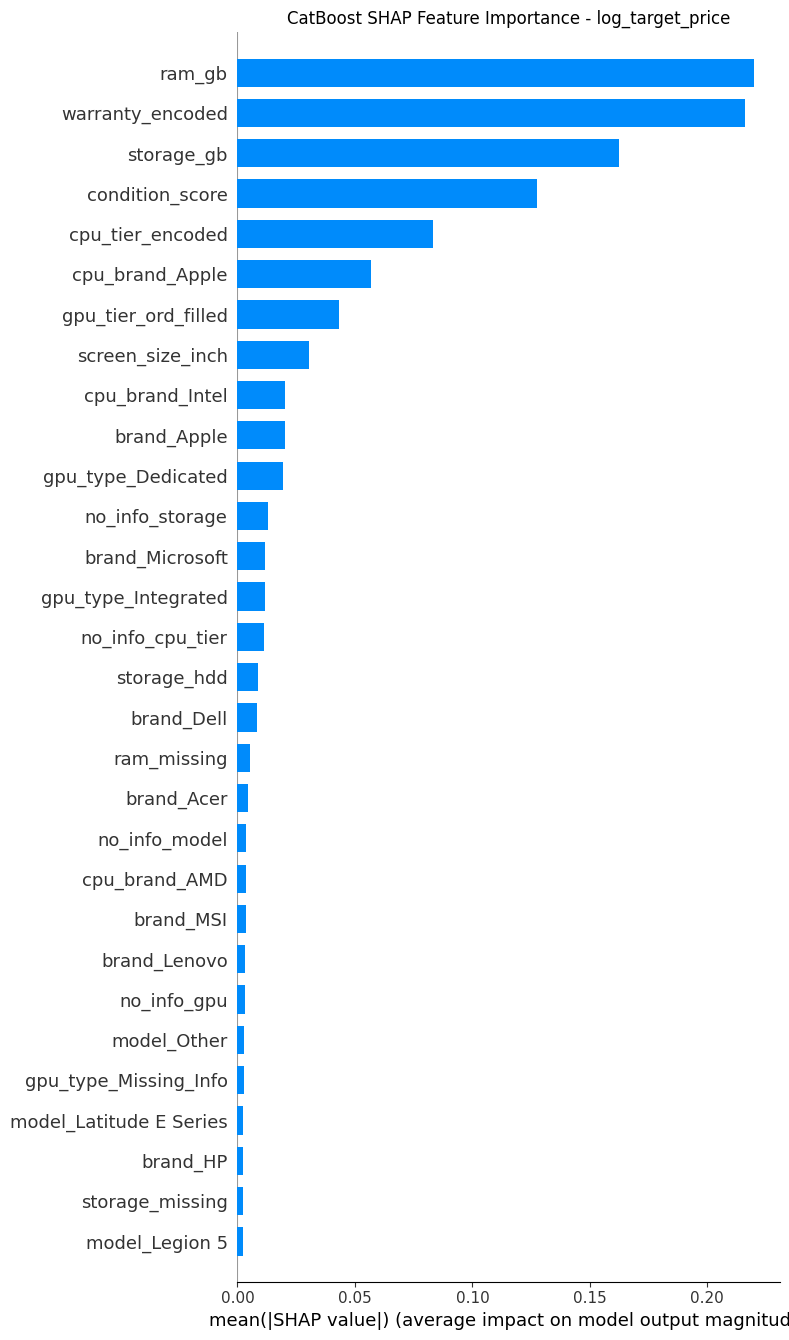

Saved SHAP bar plot: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\feature_selection\shap_summary_bar_log_target_price.png


In [324]:
for target_name, result in shap_results.items():
    suffix = safe_artifact_name(target_name)

    X_sample = result["X_sample"]
    shap_values = result["shap_values"]

    plt.figure(figsize=(10, 8))

    shap.summary_plot(
        shap_values,
        X_sample,
        plot_type="bar",
        max_display=SHAP_TOP_N,
        show=False
    )

    plt.title(f"CatBoost SHAP Feature Importance - {target_name}")
    plt.tight_layout()

    bar_path = FEATURE_SEL_DIR / f"shap_summary_bar_{suffix}.png"
    plt.savefig(bar_path, dpi=160, bbox_inches="tight")
    plt.show()

    print(f"Saved SHAP bar plot: {bar_path}")

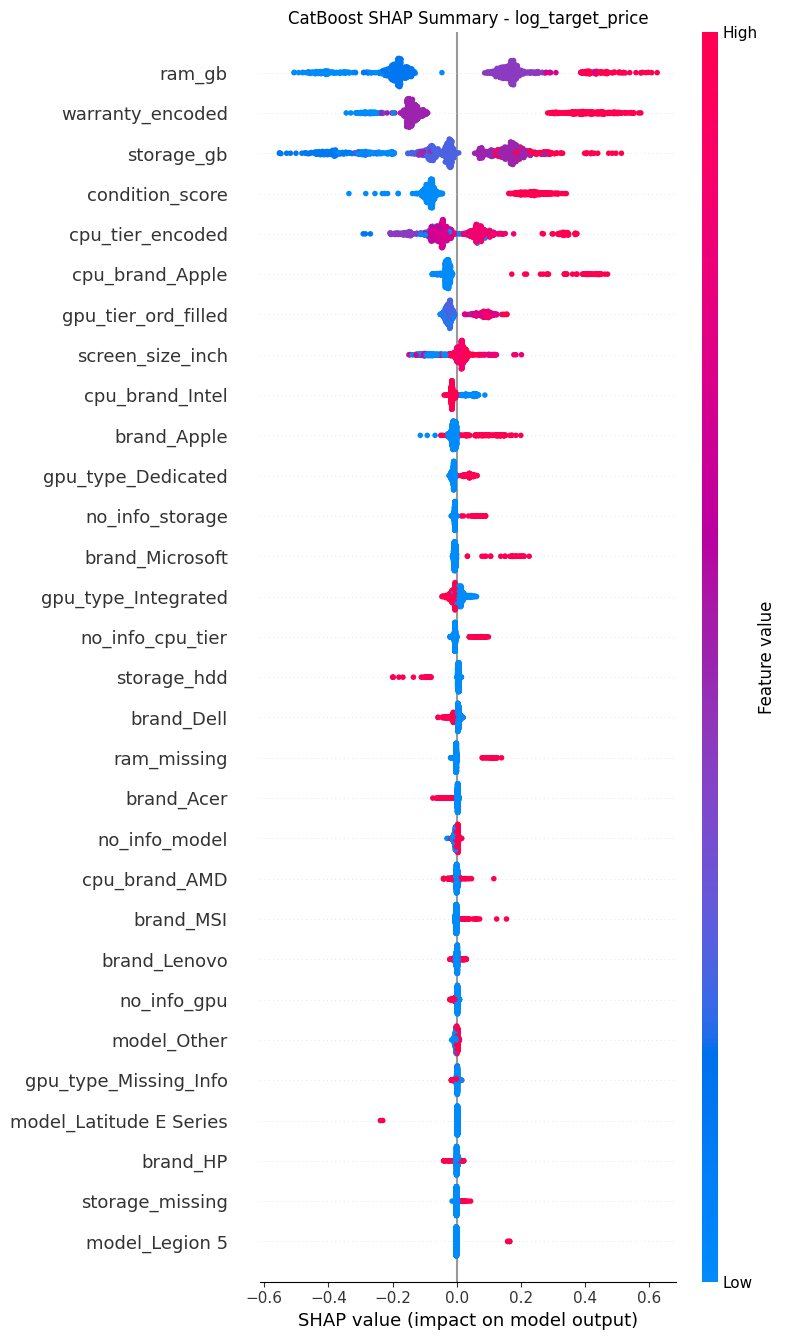

Saved SHAP beeswarm plot: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\feature_selection\shap_summary_beeswarm_log_target_price.png


In [325]:
for target_name, result in shap_results.items():
    suffix = safe_artifact_name(target_name)

    X_sample = result["X_sample"]
    shap_values = result["shap_values"]

    plt.figure(figsize=(10, 8))

    shap.summary_plot(
        shap_values,
        X_sample,
        max_display=SHAP_TOP_N,
        show=False
    )

    plt.title(f"CatBoost SHAP Summary - {target_name}")
    plt.tight_layout()

    beeswarm_path = FEATURE_SEL_DIR / f"shap_summary_beeswarm_{suffix}.png"
    plt.savefig(beeswarm_path, dpi=160, bbox_inches="tight")
    plt.show()

    print(f"Saved SHAP beeswarm plot: {beeswarm_path}")

### Nhận xét Beeswarm SHAP cho `target_price`

The SHAP beeswarm plot for `target_price` shows that the model output is strongly affected by a small group of dominant features, especially `warranty_encoded`, `ram_gb`, `storage_gb`, `condition_score`, and `cpu_tier_encoded`.

For `warranty_encoded`, high feature values are mostly located on the positive SHAP side. This means that better or stronger warranty-related values tend to increase the predicted price. In contrast, low warranty values are closer to the negative or near-zero SHAP region, indicating a lower contribution to the predicted price.

For `ram_gb`, higher RAM values clearly push the prediction upward, while lower RAM values tend to reduce the predicted price. This confirms that RAM capacity is one of the most important hardware specifications in the raw-price model.

A similar pattern appears for `storage_gb`. Higher storage capacity generally produces positive SHAP values, meaning it increases the predicted price. Lower storage values are mostly associated with negative or near-zero SHAP values.

The feature `condition_score` also has a strong positive impact when its value is high. This suggests that missing condition information is not random and may be associated with certain laptop price segments. Therefore, this feature should be reviewed carefully because it may capture dataset-specific behavior rather than a direct technical property of the laptop.

For `cpu_tier_encoded`, higher CPU tiers generally increase the predicted price, although the points are more spread out. This indicates that CPU tier is important, but its effect may interact with other features such as brand, RAM, GPU, and storage.

Overall, the `target_price` beeswarm plot suggests that the raw-price model is highly sensitive to absolute price drivers. Warranty, RAM, storage, condition information, CPU tier, Apple-related features, and GPU tier are the main factors increasing or decreasing the predicted laptop price.

---

### Nhận xét Beeswarm SHAP cho `log_target_price`

The SHAP beeswarm plot for `log_target_price` shows a more balanced pattern compared with the raw target. The strongest features are `ram_gb`, `condition_score`, `storage_gb`, `warranty_encoded`, and `cpu_tier_encoded`.

For `ram_gb`, high RAM values clearly move SHAP values to the positive side, while low RAM values move them to the negative side. This indicates that RAM is the most stable and influential feature when predicting log-transformed price.

The feature `condition_score` has a strong positive contribution when its value is high. This again suggests that missing condition information carries predictive signal. However, since this is a missingness indicator rather than a direct product specification, it should be interpreted with caution.

For `storage_gb`, high values generally increase the predicted log price, while low values decrease it. Compared with the raw target, the effect is still clear but less extreme, which is expected because log transformation compresses large price differences.

For `warranty_encoded`, high values also tend to increase the predicted log price. However, its dominance is lower than in the raw target. This suggests that warranty status has a strong effect on absolute price, but after log transformation, its influence becomes more balanced with other core specifications.

For `cpu_tier_encoded`, higher CPU tiers mostly contribute positively, while lower CPU tiers tend to reduce the prediction. The spread of points shows that CPU tier remains important, but its impact is not as dominant as RAM, storage, warranty, or condition-related information.

Overall, the `log_target_price` beeswarm plot suggests that the log-transformed model relies more consistently on core hardware features. RAM, storage, CPU tier, and warranty remain important, but the impact distribution is less extreme than in the raw-price model.

---

### So sánh hai Beeswarm Plot

The two beeswarm plots show that both targets rely on similar important features, but their impact patterns are different.

For `target_price`, the SHAP values have a much wider range. Some features, especially `ram_gb` and `storage_gb`, produce very large positive SHAP values. This means the raw-price model is more sensitive to high-price laptops and premium configurations.

For `log_target_price`, the SHAP values are compressed into a smaller range. This is expected because the log transformation reduces the effect of extreme price values. As a result, the model explanation becomes more stable and less dominated by very expensive laptops.

The most consistent positive drivers across both targets are:

- `ram_gb`
- `storage_gb`
- `warranty_encoded`
- `cpu_tier_encoded`
- `cpu_brand_Apple`
- `gpu_tier_ord_filled`
- `gpu_type_Dedicated`

The most important caution is the repeated high importance of `condition_score`. Since this feature represents missing information, not an actual laptop specification, it may indicate a data-quality or listing-behavior effect. This feature should be tested in later ablation experiments to see whether removing it reduces generalization or simply removes a dataset artifact.

---

### Kết luận từ Beeswarm Plot

The SHAP beeswarm plots confirm that the CatBoost model mainly learns price patterns from hardware specifications, warranty status, condition-related information, and brand/model indicators.

The raw target `target_price` is more affected by extreme positive contributions, especially from high RAM, high storage, and strong warranty signals. In contrast, `log_target_price` produces a more balanced explanation, where RAM, storage, warranty, and CPU tier contribute more consistently across the dataset.

Therefore, `log_target_price` may be more suitable for stable feature interpretation, while `target_price` is useful for understanding absolute price changes and high-price laptop behavior.

## 10. Data Preparation for Retraining Experiments

Tạo một **single shared 80/20 split** dùng chung cho tất cả experiments ở Section 11.

> **Nguyên tắc:** Mọi experiment phải dùng cùng `train_idx` / `test_idx` để metric có thể so sánh công bằng.
> `df` gốc không được overwrite; mỗi experiment tự tạo bản copy riêng.

In [326]:
# ============================================================
# 10.1  Load & validate data
# ============================================================

TARGET_PRICE_COL    = "target_price"
TARGET_LOG_PRICE_COL = "log_target_price"
SEGMENT_COL         = "price_segment"

df = pd.read_csv(DATA_PATH)
print("Data shape:", df.shape)

# Tự sinh log_target_price nếu chưa có
if TARGET_LOG_PRICE_COL not in df.columns and TARGET_PRICE_COL in df.columns:
    df[TARGET_LOG_PRICE_COL] = np.log1p(df[TARGET_PRICE_COL])
    print("[INFO] log_target_price derived via np.log1p")

for col in [TARGET_PRICE_COL, TARGET_LOG_PRICE_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Loại bỏ rows có target không hợp lệ
before = len(df)
df = df[df[TARGET_PRICE_COL].notna() & df[TARGET_LOG_PRICE_COL].notna() & (df[TARGET_PRICE_COL] > 0)].copy()
df = df.reset_index(drop=True)
print(f"Rows removed (invalid target): {before - len(df)}  |  Final shape: {df.shape}")


Data shape: (7208, 77)
Rows removed (invalid target): 0  |  Final shape: (7208, 77)


In [327]:
# ============================================================
# 10.2  Shared targets & price segment
# ============================================================

y_log   = df[TARGET_LOG_PRICE_COL].reset_index(drop=True)
y_price = df[TARGET_PRICE_COL].reset_index(drop=True)

# Dùng segment column có sẵn; nếu không có thì tạo từ quantile
if SEGMENT_COL in df.columns:
    price_segment = df[SEGMENT_COL].reset_index(drop=True)
    print(f"Using existing segment column: {SEGMENT_COL}")
else:
    price_segment = pd.qcut(
        y_price, q=4,
        labels=["Low", "Mid", "High", "Premium"],
        duplicates="drop",
    )
    price_segment = pd.Series(price_segment, name=SEGMENT_COL).reset_index(drop=True)
    print("Segment column created from quantile cut")

print("\nSegment distribution:")
print(price_segment.value_counts().sort_index())


Segment column created from quantile cut

Segment distribution:
price_segment
Low        1818
Mid        1825
High       1773
Premium    1792
Name: count, dtype: int64


In [328]:
# ============================================================
# 10.3  Shared 80/20 stratified split  (chỉ tạo 1 lần)
# ============================================================

all_idx = np.arange(len(df))

train_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=price_segment,
)

seg_train = price_segment.iloc[train_idx].reset_index(drop=True)
seg_test  = price_segment.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(train_idx)}  |  Test: {len(test_idx)}")
print("\nTrain segment counts:")
print(seg_train.value_counts().sort_index())
print("\nTest segment counts:")
print(seg_test.value_counts().sort_index())


Train: 5766  |  Test: 1442

Train segment counts:
price_segment
Low        1454
Mid        1460
High       1418
Premium    1434
Name: count, dtype: int64

Test segment counts:
price_segment
Low        364
Mid        365
High       355
Premium    358
Name: count, dtype: int64


In [329]:
# ============================================================
# 10.4  Baseline feature matrix  (numeric only, targets excluded)
# ============================================================

EXCLUDE_COLS = [TARGET_PRICE_COL, TARGET_LOG_PRICE_COL, SEGMENT_COL]
EXCLUDE_COLS = [c for c in EXCLUDE_COLS if c in df.columns]

X_baseline = (
    df.drop(columns=EXCLUDE_COLS)
      .select_dtypes(include=[np.number])
      .copy()
)

print("X_baseline shape:", X_baseline.shape)
print("Columns:", X_baseline.columns.tolist())


X_baseline shape: (7208, 75)
Columns: ['ram_gb', 'storage_gb', 'screen_size_inch', 'brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'no_info_brand', 'no_info_model', 'no_info_cpu_brand', 'no_info_cpu_tier', 'no_info_gpu', 'storage_ssd', 'storage_hdd', 'no_info_storage', 'condition_score', 'warranty_encoded', 'cpu_tier_encoded', 'brand_ASUS', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Other', 'brand_Sony', 'brand_Toshiba', 'model_Aspire', 'model_Elitebook', 'model_Elitebook 800', 'model_Gaming Thin GF', 'model_IdeaPad', 'model_Inspiron', 'model_Latitude', 'model_Latitude 14 7000', 'model_Latitude E Series', 'model_Legion', 'model_Legion 5', 'model_MacBook Air', 'model_MacBook Air M1', 'model_MacBook Air M2', 'model_MacBook Pro', 'model_MacBook Pro M1', 'model_MacBook Pro M2', 'model_Macbook air m4', 'model_Nitro 5', 'model_Other', 'model_Pavilion 15', 'mo

In [330]:
# ============================================================
# 10.5  Helper: run one experiment with shared split
# ============================================================

def run_experiment(
    X: pd.DataFrame,
    y_log: pd.Series,
    y_price: pd.Series,
    train_idx,
    test_idx,
    seg_test: pd.Series,
    experiment_name: str,
    model_params: dict | None = None,
    sample_weight_train: np.ndarray | None = None,
    early_stopping_rounds: int | None = None,
    plot: bool = True,
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Split X/y theo shared indices, train CatBoost trên log-target,
    evaluate trên price scale. Trả về 1-row metrics DataFrame.

    Parameters
    ----------
    sample_weight_train : np.ndarray or None
        Weight cho từng sample trong train set (segment-aware weighting).
    """
    # ── split ──────────────────────────────────────────────
    X_train, X_test, y_train_log, y_test_log = make_train_test_data(
        X=X, y=y_log, train_idx=train_idx, test_idx=test_idx
    )
    _, _, y_train_price, y_test_price = make_train_test_data(
        X=X, y=y_price, train_idx=train_idx, test_idx=test_idx
    )

    print(f"[{experiment_name}] X_train={X_train.shape}  X_test={X_test.shape}")

    # ── train ──────────────────────────────────────────────
    result = run_catboost_experiment(
        experiment_name=experiment_name,
        X_train=X_train,
        y_train=y_train_log,
        X_test=X_test,
        y_test=y_test_log,            # ← truyền đúng y_test (log scale)
        y_test_price=y_test_price,    # ← dùng để tính metrics price scale
        target_name=TARGET_LOG_PRICE_COL,
        log_transform="log1p",
        model_params=model_params,
        segment_labels_test=seg_test,
        early_stopping_rounds=early_stopping_rounds,
        sample_weight=sample_weight_train,
        plot=plot,
        verbose=verbose,
    )

    metrics = pd.DataFrame([result["metrics"]])
    print(metrics[["experiment_name", "mae", "rmse", "r2", "mape_pct"]].to_string(index=False))
    return result, metrics


print("Helper run_experiment() ready.")


Helper run_experiment() ready.


## 11. Retraining Experiments

Mỗi experiment thay đổi **đúng một yếu tố** (feature engineering, encoding, weighting) so với baseline, dùng cùng split để metric so sánh được.

| Exp | Thay đổi |
|---|---|
| 11.0 | Baseline (không thay đổi) |
| 11.1 | One-hot encode `warranty_encoded` |
| 11.2 | Drop warranty so sánh (ablation) |
| 11.3 | Feature phi tuyến từ RAM / Storage |
| 11.4 | Segment-aware weighting (Premium ×3) |
| 11.5 | Kết hợp tất cả cải tiến có lợi |
| — | Tổng kết so sánh tất cả experiments |

### 11.0 Baseline

Chạy model với `X_baseline` không thay đổi để làm điểm so sánh.

[baseline] X_train=(5766, 75)  X_test=(1442, 75)


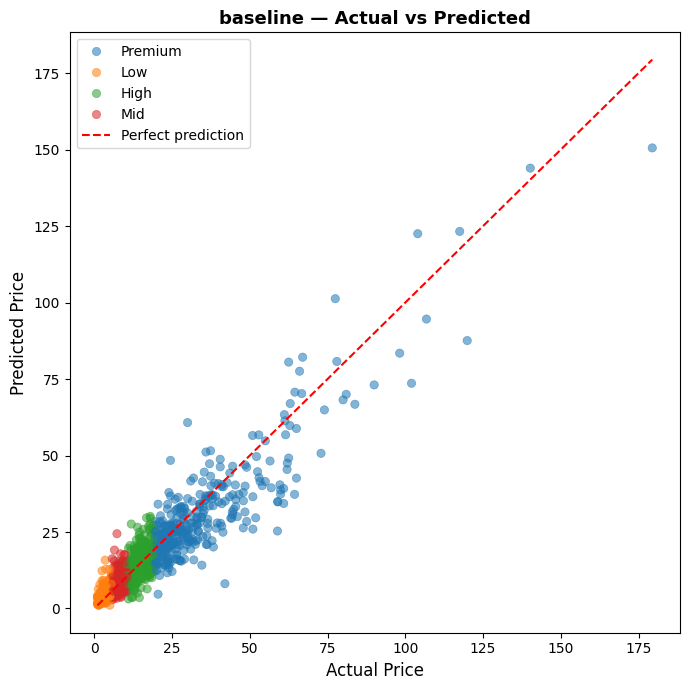

experiment_name    mae   rmse     r2  mape_pct
       baseline 3.4047 5.4937 0.8742   28.7757


In [331]:
result_baseline, metrics_baseline = run_experiment(
    X=X_baseline,
    y_log=y_log,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="baseline",
    plot=True,
)


### 11.1 Warranty Encoding: One-hot vs Ordinal

`warranty_encoded` là biến categorical với 3 trạng thái rời rạc (0=hết BH, 1=còn BH, 2=chưa active BH). One-hot loại bỏ ordering giả tạo mà ordinal encoding ngầm tạo ra.

> **Kiểm tra đúng cách:** so sánh `X_baseline` (giữ ordinal) vs `X_onehot_warranty` (thay bằng 3 dummy). Experiment 11.3 sẽ drop warranty hoàn toàn để đo contribution thực sự.

In [332]:
# ── Tạo X với one-hot warranty ─────────────────────────────
WARRANTY_COL = "warranty_encoded"

df_w = df.copy().reset_index(drop=True)
df_w[WARRANTY_COL] = pd.to_numeric(df_w[WARRANTY_COL], errors="coerce")

# Validate: chỉ 3 giá trị hợp lệ
assert df_w[WARRANTY_COL].isin([0, 1, 2]).all(), "Unexpected warranty values"

df_w["warranty_expired"]       = (df_w[WARRANTY_COL] == 0).astype(int)
df_w["warranty_active"]        = (df_w[WARRANTY_COL] == 1).astype(int)
df_w["warranty_not_activated"] = (df_w[WARRANTY_COL] == 2).astype(int)
df_w = df_w.drop(columns=[WARRANTY_COL])

X_onehot_warranty = (
    df_w.drop(columns=EXCLUDE_COLS, errors="ignore")
        .select_dtypes(include=[np.number])
        .copy()
)

# Kiểm tra warranty columns thay đổi đúng
assert WARRANTY_COL not in X_onehot_warranty.columns, "Original warranty column still present!"
new_w_cols = [c for c in X_onehot_warranty.columns if "warranty" in c]
print("Warranty columns in X_onehot_warranty:", new_w_cols)
print("X_onehot_warranty shape:", X_onehot_warranty.shape)


Warranty columns in X_onehot_warranty: ['warranty_expired', 'warranty_active', 'warranty_not_activated']
X_onehot_warranty shape: (7208, 77)


[warranty_onehot] X_train=(5766, 77)  X_test=(1442, 77)


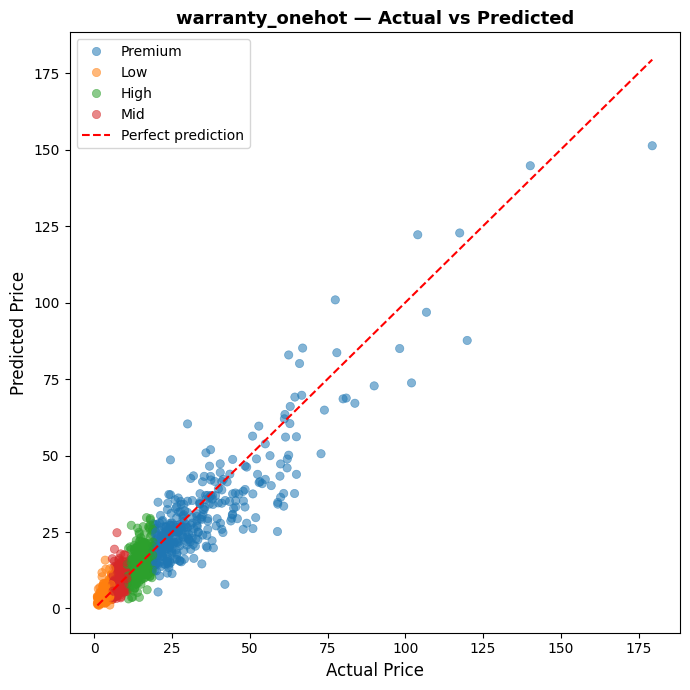

experiment_name    mae   rmse     r2  mape_pct
warranty_onehot 3.3971 5.4854 0.8746   28.7047


In [333]:
result_onehot_w, metrics_onehot_w = run_experiment(
    X=X_onehot_warranty,
    y_log=y_log,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="warranty_onehot",
    plot=True,
)


### 11.2 Boots Value Numeric Warrenty

In [334]:
# ============================================================
# Create X with remapped warranty: 0, 1, 2 -> 0, 1, 5
# Do NOT overwrite original df / X_baseline
# ============================================================

WARRANTY_COL = "warranty_encoded"

if WARRANTY_COL not in df.columns:
    raise ValueError(
        f"Column '{WARRANTY_COL}' not found. "
        f"Available columns: {df.columns.tolist()}"
    )

# Work on a copy only
df_w_015 = df.copy().reset_index(drop=True)

# Convert warranty to numeric
df_w_015[WARRANTY_COL] = pd.to_numeric(
    df_w_015[WARRANTY_COL],
    errors="coerce"
)

# Validate: only 0, 1, 2 are allowed
invalid_values = sorted(
    df_w_015.loc[
        ~df_w_015[WARRANTY_COL].isin([0, 1, 2]),
        WARRANTY_COL
    ].dropna().unique()
)

if invalid_values:
    raise ValueError(
        f"Unexpected warranty values found: {invalid_values}"
    )

if df_w_015[WARRANTY_COL].isna().any():
    raise ValueError(
        f"Missing/NaN values found in '{WARRANTY_COL}'"
    )

print("Warranty distribution before remap:")
print(df_w_015[WARRANTY_COL].value_counts().sort_index())

warranty_mapping = {
    0: 0,
    1: 1,
    2: 5,
}

df_w_015[WARRANTY_COL] = df_w_015[WARRANTY_COL].map(warranty_mapping).astype(int)

print("\nWarranty distribution after remap:")
print(df_w_015[WARRANTY_COL].value_counts().sort_index())


X_warranty_015 = (
    df_w_015
    .drop(columns=EXCLUDE_COLS, errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

# ------------------------------------------------------------
# 4. Validate result
# ------------------------------------------------------------

assert WARRANTY_COL in X_warranty_015.columns, "Remapped warranty column missing!"
assert set(X_warranty_015[WARRANTY_COL].unique()).issubset({0, 1, 5}), \
    "Warranty remap failed!"

print("\nWarranty values in X_warranty_015:")
print(sorted(X_warranty_015[WARRANTY_COL].unique()))

print("\nX_warranty_015 shape:", X_warranty_015.shape)

Warranty distribution before remap:
warranty_encoded
0     429
1    4913
2    1866
Name: count, dtype: int64

Warranty distribution after remap:
warranty_encoded
0     429
1    4913
5    1866
Name: count, dtype: int64

Warranty values in X_warranty_015:
[0, 1, 5]

X_warranty_015 shape: (7208, 75)


[warranty_015] X_train=(5766, 75)  X_test=(1442, 75)


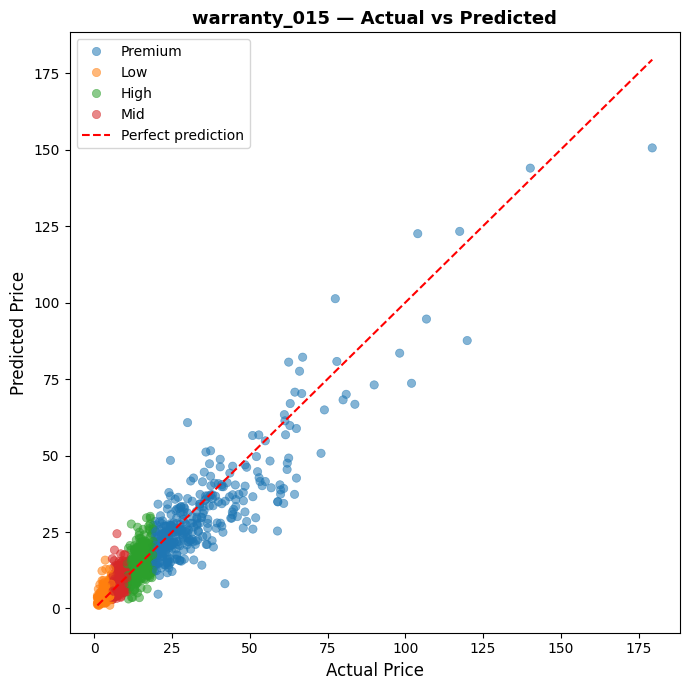

experiment_name    mae   rmse     r2  mape_pct
   warranty_015 3.4047 5.4937 0.8742   28.7757


In [335]:
result_warranty_015, metrics_warranty_015 = run_experiment(
    X=X_warranty_015,
    y_log=y_log,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="warranty_015",
    plot=True,
)

không có sự khác biệt đối với baseline, vậy độ lớn của giá trị numeric ko ảnh hưởng bằng thứ tự độ lớn

### 11.3 Ablation: Drop Warranty Hoàn Toàn

Nếu MAE/R² không đổi khi drop `warranty_encoded`, feature này không đóng góp thực sự và nên loại bỏ. Nếu metric xấu đi → warranty có signal thật.

In [336]:
# Drop tất cả warranty columns
warranty_cols_to_drop = [c for c in X_baseline.columns if "warranty" in c.lower()]
print("Dropping:", warranty_cols_to_drop)

X_no_warranty = X_baseline.drop(columns=warranty_cols_to_drop, errors="ignore").copy()
print("X_no_warranty shape:", X_no_warranty.shape)


Dropping: ['warranty_encoded']
X_no_warranty shape: (7208, 74)


In [337]:
result_no_w, metrics_no_w = run_experiment(
    X=X_no_warranty,
    y_log=y_log,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="ablation_drop_warranty",
    plot=False,  # không cần plot cho ablation thuần
)


[ablation_drop_warranty] X_train=(5766, 74)  X_test=(1442, 74)
       experiment_name    mae   rmse     r2  mape_pct
ablation_drop_warranty 3.4689 5.6351 0.8676   29.5294


**Đọc kết quả ablation warranty:**
- `ablation_drop_warranty` MAE **tăng** so với `baseline` → warranty có signal thật → **nên giữ**.
- So sánh tiếp với `warranty_onehot`: nếu one-hot tốt hơn baseline → encoding quan trọng hơn là signal.


### 11.3 Feature Phi Tuyến từ RAM / Storage

CatBoost là tree-based — **bất biến với monotonic scaling** (`ram_gb / 512` cho kết quả giống hệt `ram_gb`). Các feature thực sự mới cần tạo ra **information chưa có** trong data:

- `ram_storage_ratio`: tỷ lệ RAM/Storage phản ánh cân bằng workload
- `log_ram_gb`, `log_storage_gb`: compress tail distribution của high-end laptops  
- `ram_tier`, `storage_tier`: bucketize theo ngưỡng thị trường thực tế
- `is_high_ram`: binary flag cho laptops ≥32GB (workstation/pro segment)

In [338]:
# ============================================================
# Create X with only high-spec indicator features
# Do NOT overwrite original df / X_baseline
# ============================================================

df_high = df.copy().reset_index(drop=True)

RAM_COL = "ram_gb"
STORAGE_COL = "storage_gb"

# ------------------------------------------------------------
# 1. Validate required columns
# ------------------------------------------------------------

missing_cols = [
    col for col in [RAM_COL, STORAGE_COL]
    if col not in df_high.columns
]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# ------------------------------------------------------------
# 2. Convert to numeric
# ------------------------------------------------------------

df_high[RAM_COL] = pd.to_numeric(df_high[RAM_COL], errors="coerce")
df_high[STORAGE_COL] = pd.to_numeric(df_high[STORAGE_COL], errors="coerce")

# ------------------------------------------------------------
# 3. Create high-spec flags
# ------------------------------------------------------------

df_high["is_high_ram_16"] = (df_high[RAM_COL] >= 16).astype(int)
df_high["is_high_ram_32"] = (df_high[RAM_COL] >= 32).astype(int)

df_high["is_large_storage_512"] = (df_high[STORAGE_COL] >= 512).astype(int)
df_high["is_large_storage_1024"] = (df_high[STORAGE_COL] >= 1024).astype(int)

df_high["is_high_ram_large_storage"] = (
    (df_high[RAM_COL] >= 16) &
    (df_high[STORAGE_COL] >= 512)
).astype(int)

# ------------------------------------------------------------
# 4. Create numeric feature matrix
# ------------------------------------------------------------

X_high_spec = (
    df_high
    .drop(columns=EXCLUDE_COLS, errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

# ------------------------------------------------------------
# 5. Keep baseline + only new high-spec flags
# ------------------------------------------------------------

high_spec_features = [
    "is_high_ram_16",
    "is_high_ram_32",
    "is_large_storage_512",
    "is_large_storage_1024",
    "is_high_ram_large_storage",
]

high_spec_cols = X_baseline.columns.tolist() + high_spec_features
high_spec_cols = [c for c in high_spec_cols if c in X_high_spec.columns]

X_high_spec_only = X_high_spec[high_spec_cols].copy()

print("New high-spec features:", high_spec_features)
print("Actually added:", [c for c in X_high_spec_only.columns if c not in X_baseline.columns])
print("X_high_spec_only shape:", X_high_spec_only.shape)

print("\nHigh-spec feature distribution:")
display(X_high_spec_only[high_spec_features].agg(["mean", "sum"]).T)

New high-spec features: ['is_high_ram_16', 'is_high_ram_32', 'is_large_storage_512', 'is_large_storage_1024', 'is_high_ram_large_storage']
Actually added: ['is_high_ram_16', 'is_high_ram_32', 'is_large_storage_512', 'is_large_storage_1024', 'is_high_ram_large_storage']
X_high_spec_only shape: (7208, 80)

High-spec feature distribution:


,mean,sum
is_high_ram_16,0.4979,"3,589.0000"
is_high_ram_32,0.0910,656.0000
is_large_storage_512,0.4824,"3,477.0000"
is_large_storage_1024,0.1340,966.0000
is_high_ram_large_storage,0.3661,"2,639.0000"


[rs_high_spec_flags] X_train=(5766, 80)  X_test=(1442, 80)


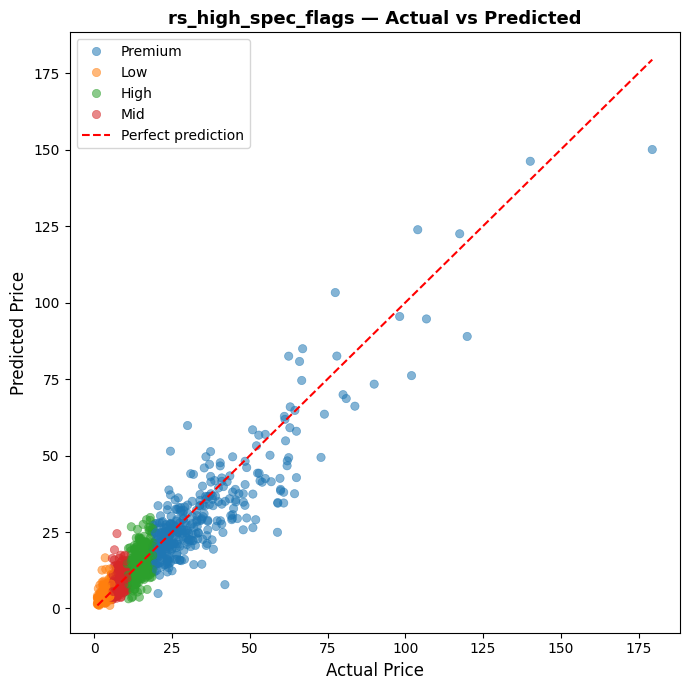

   experiment_name    mae   rmse     r2  mape_pct
rs_high_spec_flags 3.3877 5.4825 0.8747   28.6189


In [339]:
# ============================================================
# Run experiment: high-spec RAM / Storage flags only
# ============================================================

result_high_spec, metrics_high_spec = run_experiment(
    X=X_high_spec_only,
    y_log=y_log,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="rs_high_spec_flags",
    plot=True,
)

In [340]:
df_rs2 = df.copy().reset_index(drop=True)

RAM_COL = "ram_gb"
STORAGE_COL = "storage_gb"

for col in [RAM_COL, STORAGE_COL]:
    if col not in df_rs2.columns:
        raise ValueError(f"Missing required column: {col}")
    df_rs2[col] = pd.to_numeric(df_rs2[col], errors="coerce")

df_rs2["ram_storage_product_scaled"] = (
    df_rs2[RAM_COL] * df_rs2[STORAGE_COL]
) / (16 * 512)

df_rs2["ram_storage_balance"] = np.minimum(
    df_rs2[RAM_COL] / 16,
    df_rs2[STORAGE_COL] / 512
)

df_rs2["memory_storage_score"] = (
    2.0 * np.log1p(df_rs2[RAM_COL]) +
    1.0 * np.log1p(df_rs2[STORAGE_COL])
)

df_rs2["is_entry_memory_storage"] = (
    (df_rs2[RAM_COL] <= 8) &
    (df_rs2[STORAGE_COL] <= 256)
).astype(int)

df_rs2["is_mid_memory_storage"] = (
    (df_rs2[RAM_COL] >= 16) &
    (df_rs2[STORAGE_COL] >= 512)
).astype(int)

df_rs2["is_premium_memory_storage"] = (
    (df_rs2[RAM_COL] >= 32) &
    (df_rs2[STORAGE_COL] >= 1024)
).astype(int)

X_rs2_all = (
    df_rs2
    .drop(columns=EXCLUDE_COLS, errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

rs2_features = [
    "ram_storage_product_scaled",
    "ram_storage_balance",
    "memory_storage_score",
    "is_entry_memory_storage",
    "is_mid_memory_storage",
    "is_premium_memory_storage",
]

# Keep baseline + only new RAM/Storage features
rs2_cols = X_baseline.columns.tolist() + rs2_features
rs2_cols = [c for c in rs2_cols if c in X_rs2_all.columns]

X_rs2 = X_rs2_all[rs2_cols].copy()

print("New RAM/Storage features:", rs2_features)
print("Actually added:", [c for c in X_rs2.columns if c not in X_baseline.columns])
print("X_rs2 shape:", X_rs2.shape)

display(
    X_rs2[rs2_features]
    .describe()
    .T[["mean", "min", "50%", "max"]]
)

New RAM/Storage features: ['ram_storage_product_scaled', 'ram_storage_balance', 'memory_storage_score', 'is_entry_memory_storage', 'is_mid_memory_storage', 'is_premium_memory_storage']
Actually added: ['ram_storage_product_scaled', 'ram_storage_balance', 'memory_storage_score', 'is_entry_memory_storage', 'is_mid_memory_storage', 'is_premium_memory_storage']
X_rs2 shape: (7208, 81)


,mean,min,50%,max
ram_storage_product_scaled,1.0039,0.0000,0.5000,144.0000
ram_storage_balance,0.6800,0.0000,0.5000,12.0000
memory_storage_score,10.5216,0.0000,10.6347,19.2488
is_entry_memory_storage,0.3647,0.0000,0.0000,1.0000
is_mid_memory_storage,0.3661,0.0000,0.0000,1.0000
is_premium_memory_storage,0.0533,0.0000,0.0000,1.0000


### Observation

Kết quả ablation cho thấy việc tạo thêm các feature từ `ram_gb` và `storage_gb` không tạo ra cải thiện quá lớn so với baseline. Điều này khá hợp lý vì CatBoost đã có khả năng tự học các quan hệ phi tuyến và các ngưỡng split trực tiếp từ hai feature gốc này. Do đó, các biến đổi như tích RAM–Storage, balance score hoặc combined score có thể không bổ sung thêm nhiều thông tin mới cho mô hình.

Trong các feature được thử nghiệm riêng lẻ, `is_mid_memory_storage` cho kết quả tốt nhất tổng thể. Feature này đạt RMSE thấp nhất và R² cao nhất trong nhóm, cho thấy ngưỡng `RAM >= 16GB` và `Storage >= 512GB` có thể đại diện cho một phân khúc laptop trung/cao cấp có ý nghĩa trên thị trường. Đây là loại feature có tính diễn giải tốt hơn so với các phép biến đổi số học đơn thuần.

Ngược lại, `is_premium_memory_storage` không cho kết quả tốt bằng dù về mặt trực giác nó đại diện cho nhóm máy cao cấp hơn. Nguyên nhân có thể là nhóm laptop có `RAM >= 32GB` và `Storage >= 1024GB` có số lượng mẫu ít hơn, hoặc giá của nhóm này phụ thuộc mạnh hơn vào các yếu tố khác như CPU, GPU, brand, dòng máy, tình trạng sản phẩm và warranty.

Nhìn chung, kết quả cho thấy không nên thêm toàn bộ nhóm RAM/Storage engineered features vào mô hình. Các feature này có thể làm feature set phức tạp hơn nhưng không đem lại cải thiện rõ ràng. Nếu cần giữ lại một feature từ nhóm này, `is_mid_memory_storage` là lựa chọn hợp lý nhất để tiếp tục kiểm tra so với baseline chính.

Bước tiếp theo nên là so sánh trực tiếp `X_baseline` với phiên bản chỉ thêm `is_mid_memory_storage`. Nếu cải thiện vẫn rất nhỏ hoặc không ổn định, nên giữ nguyên baseline và không thêm feature RAM/Storage mới. Trong trường hợp mục tiêu chính là giảm lỗi ở nhóm laptop cấu hình cao, hướng phù hợp hơn có thể là thử sample weighting cho nhóm premium thay vì tiếp tục tạo thêm feature từ RAM và Storage.

In [341]:
# ============================================================
# RAM / Storage relative-to-brand features
# Brand is already one-hot encoded with prefix "brand_"
# Avoid overwriting original df / X_baseline
# ============================================================

df_rel = df.copy().reset_index(drop=True)

RAM_COL = "ram_gb"
STORAGE_COL = "storage_gb"
BRAND_PREFIX = "brand_"

# ------------------------------------------------------------
# 1. Validate required numeric columns
# ------------------------------------------------------------

for col in [RAM_COL, STORAGE_COL]:
    if col not in df_rel.columns:
        raise ValueError(f"Missing required column: {col}")

df_rel[RAM_COL] = pd.to_numeric(df_rel[RAM_COL], errors="coerce")
df_rel[STORAGE_COL] = pd.to_numeric(df_rel[STORAGE_COL], errors="coerce")

# ------------------------------------------------------------
# 2. Detect one-hot brand columns
# ------------------------------------------------------------

brand_cols = [
    c for c in df_rel.columns
    if c.startswith(BRAND_PREFIX)
]

if len(brand_cols) == 0:
    raise ValueError(
        f"No one-hot brand columns found with prefix '{BRAND_PREFIX}'"
    )

print("Detected brand one-hot columns:")
print(brand_cols)

# ------------------------------------------------------------
# 3. Reconstruct temporary brand group from one-hot columns
# ------------------------------------------------------------

brand_ohe = df_rel[brand_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# If one brand column is 1, use that column name as group.
# If all are 0, mark as unknown_brand.
df_rel["_brand_group_tmp"] = brand_ohe.idxmax(axis=1)

no_brand_mask = brand_ohe.sum(axis=1) == 0
df_rel.loc[no_brand_mask, "_brand_group_tmp"] = "unknown_brand"

print("\nTemporary brand group distribution:")
print(df_rel["_brand_group_tmp"].value_counts())

# Optional validation: check rows with more than one active brand
multi_brand_mask = brand_ohe.sum(axis=1) > 1
print("\nRows with multiple active brand columns:", multi_brand_mask.sum())

# ------------------------------------------------------------
# 4. Median RAM / Storage by reconstructed brand group
# ------------------------------------------------------------

brand_ram_median = df_rel.groupby("_brand_group_tmp")[RAM_COL].transform("median")
brand_storage_median = df_rel.groupby("_brand_group_tmp")[STORAGE_COL].transform("median")

df_rel["ram_vs_brand_median"] = (
    df_rel[RAM_COL] / brand_ram_median.replace(0, np.nan)
)

df_rel["storage_vs_brand_median"] = (
    df_rel[STORAGE_COL] / brand_storage_median.replace(0, np.nan)
)

df_rel["ram_minus_brand_median"] = (
    df_rel[RAM_COL] - brand_ram_median
)

df_rel["storage_minus_brand_median"] = (
    df_rel[STORAGE_COL] - brand_storage_median
)

rel_features = [
    "ram_vs_brand_median",
    "storage_vs_brand_median",
    "ram_minus_brand_median",
    "storage_minus_brand_median",
]

# ------------------------------------------------------------
# 5. Create numeric feature matrix
# ------------------------------------------------------------

X_rel_all = (
    df_rel
    .drop(columns=EXCLUDE_COLS + ["_brand_group_tmp"], errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

# Keep baseline + only new relative features
rel_cols = X_baseline.columns.tolist() + rel_features
rel_cols = [c for c in rel_cols if c in X_rel_all.columns]

X_rs_relative_brand = X_rel_all[rel_cols].copy()

print("\nAdded features:", [c for c in X_rs_relative_brand.columns if c not in X_baseline.columns])
print("X_rs_relative_brand shape:", X_rs_relative_brand.shape)

display(
    X_rs_relative_brand[rel_features]
    .describe()
    .T[["mean", "min", "50%", "max"]]
)

Detected brand one-hot columns:
['brand_is_rare', 'brand_ASUS', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Other', 'brand_Sony', 'brand_Toshiba']

Temporary brand group distribution:
_brand_group_tmp
brand_Dell         1933
brand_Lenovo       1060
brand_Apple         993
brand_HP            930
brand_ASUS          861
brand_Acer          484
brand_MSI           306
brand_Other         299
brand_Microsoft     247
brand_is_rare        95
Name: count, dtype: int64

Rows with multiple active brand columns: 95

Added features: ['ram_vs_brand_median', 'storage_vs_brand_median', 'ram_minus_brand_median', 'storage_minus_brand_median']
X_rs_relative_brand shape: (7208, 79)


,mean,min,50%,max
ram_vs_brand_median,1.3281,0.0000,1.0000,24.0000
storage_vs_brand_median,1.3419,0.0000,1.0000,32.0000
ram_minus_brand_median,2.5203,-16.0000,0.0000,184.0000
storage_minus_brand_median,90.3719,-512.0000,0.0000,"7,936.0000"


[rs_relative_brand_ohe] X_train=(5766, 79)  X_test=(1442, 79)


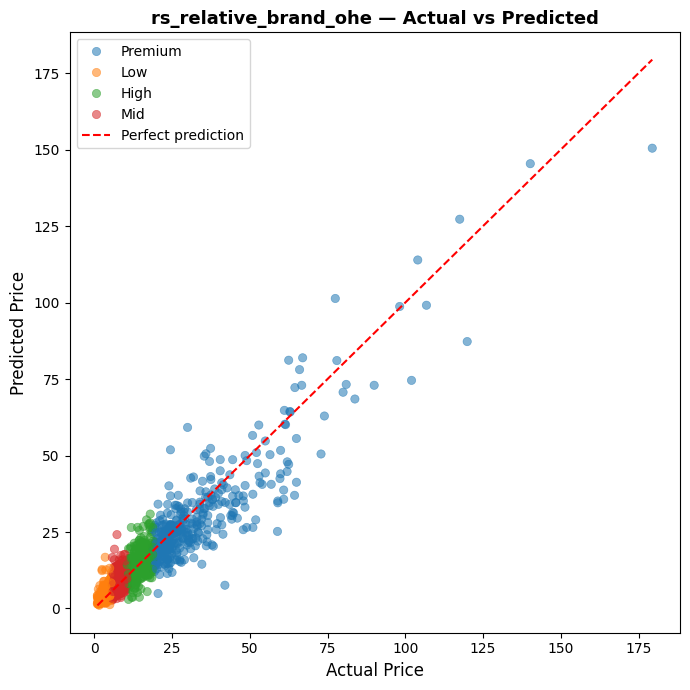

      experiment_name    mae   rmse     r2  mape_pct
rs_relative_brand_ohe 3.3978 5.4591 0.8758   28.9658


In [342]:
result_rs_relative_brand, metrics_rs_relative_brand = run_experiment(
    X=X_rs_relative_brand,
    y_log=y_log,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="rs_relative_brand_ohe",
    plot=True,
)

### Observation

Kết quả so sánh cho thấy `rs_relative_brand_ohe` cải thiện tốt hơn baseline ở hầu hết các metric chính. Baseline đạt MAE = 3.4048, RMSE = 5.5242 và R² = 0.8728, trong khi phiên bản thêm RAM/Storage relative-to-brand đạt MAE = 3.3989, RMSE = 5.4676 và R² = 0.8754.

Mức cải thiện lớn nhất nằm ở RMSE, giảm từ 5.5242 xuống 5.4676. Điều này cho thấy các feature tương đối theo brand giúp mô hình giảm tốt hơn các lỗi dự đoán lớn. R² cũng tăng từ 0.8728 lên 0.8754, cho thấy mô hình giải thích được nhiều biến thiên của giá hơn so với baseline.

MAE chỉ giảm nhẹ từ 3.4048 xuống 3.3989, nghĩa là mức cải thiện về sai số trung bình tuyệt đối không quá lớn. Tuy nhiên, việc RMSE giảm rõ hơn MAE cho thấy nhóm feature mới có thể hữu ích hơn trong việc xử lý các case có sai số lớn, thay vì cải thiện đồng đều trên toàn bộ tập test.

MAPE tăng nhẹ từ 28.6807% lên 28.8652%. Điều này cho thấy mặc dù mô hình dự đoán tốt hơn về sai số tuyệt đối và RMSE, sai số tương đối theo phần trăm chưa được cải thiện. Vì vậy, `rs_relative_brand_ohe` phù hợp hơn nếu ưu tiên giảm lỗi lớn và tăng R², nhưng cần cân nhắc nếu mục tiêu chính là tối ưu MAPE.

Nhìn chung, các feature RAM/Storage relative-to-brand có tín hiệu tốt hơn các feature RAM/Storage interaction đơn thuần. Việc so sánh RAM và Storage của một laptop với mặt bằng cùng brand bổ sung thêm ngữ cảnh thị trường cho mô hình, giúp phân biệt tốt hơn giữa các cấu hình có cùng RAM/Storage nhưng thuộc các brand khác nhau.

Dựa trên kết quả hiện tại, `rs_relative_brand_ohe` là một candidate đáng giữ lại để tiếp tục kiểm tra. Nếu các experiment tiếp theo vẫn cho thấy RMSE và R² cải thiện ổn định, nhóm feature này có thể được đưa vào clean feature set cuối cùng.

### 11.5 Config Core

In [343]:
RANDOM_STATE = 42

df_premium = df.copy().reset_index(drop=True)

# ------------------------------------------------------------
# 1. Required columns
# ------------------------------------------------------------

required_cols = [
    "ram_gb",
    "storage_gb",
    "gpu_tier_ord_filled",
    "gpu_type_Dedicated",
    "cpu_tier_encoded",
    "condition_score",
    "warranty_encoded",
]

missing_cols = [c for c in required_cols if c not in df_premium.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

numeric_cols = [
    "ram_gb",
    "storage_gb",
    "gpu_tier_ord_filled",
    "gpu_type_Dedicated",
    "cpu_tier_encoded",
    "condition_score",
    "warranty_encoded",
]

for col in numeric_cols:
    df_premium[col] = pd.to_numeric(df_premium[col], errors="coerce")

# Fill only for feature construction safety
ram = df_premium["ram_gb"].fillna(0)
storage = df_premium["storage_gb"].fillna(0)
gpu_tier = df_premium["gpu_tier_ord_filled"].fillna(0)
gpu_dedicated = df_premium["gpu_type_Dedicated"].fillna(0)
cpu_tier = df_premium["cpu_tier_encoded"].fillna(0)
condition_score = df_premium["condition_score"].fillna(0)
warranty = df_premium["warranty_encoded"].fillna(-1)

In [344]:
# ============================================================
# 2. Create premium signal features
# ============================================================

# ------------------------------------------------------------
# A. Premium config score
# ------------------------------------------------------------

df_premium["premium_config_score"] = (
    1.5 * (ram >= 16).astype(int)
    + 2.0 * (ram >= 32).astype(int)
    + 1.0 * (storage >= 512).astype(int)
    + 1.5 * (storage >= 1024).astype(int)
    + 1.5 * (gpu_tier >= 3).astype(int)
    + 1.0 * (gpu_dedicated == 1).astype(int)
    + 1.0 * (cpu_tier >= 3).astype(int)
)

# ------------------------------------------------------------
# B. GPU interaction features
# ------------------------------------------------------------

df_premium["is_high_gpu_config"] = (
    (gpu_tier >= 3) | (gpu_dedicated == 1)
).astype(int)

df_premium["is_high_gpu_with_high_ram"] = (
    ((gpu_tier >= 3) | (gpu_dedicated == 1))
    & (ram >= 16)
).astype(int)

df_premium["is_high_gpu_with_large_storage"] = (
    ((gpu_tier >= 3) | (gpu_dedicated == 1))
    & (storage >= 512)
).astype(int)

# ------------------------------------------------------------
# C. Apple premium feature
# ------------------------------------------------------------

brand_apple = df_premium["brand_Apple"] if "brand_Apple" in df_premium.columns else 0
cpu_brand_apple = df_premium["cpu_brand_Apple"] if "cpu_brand_Apple" in df_premium.columns else 0

df_premium["is_apple_premium"] = (
    ((brand_apple == 1) | (cpu_brand_apple == 1))
    & ((ram >= 16) | (storage >= 512))
).astype(int)

# ------------------------------------------------------------
# D. Condition / warranty interaction
# ------------------------------------------------------------

df_premium["condition_warranty_risk"] = (
    condition_score.astype(int)
    + (warranty == 0).astype(int)
)

df_premium["is_uncertain_condition_no_warranty"] = (
    (condition_score == 0)
    & (warranty == 0)
).astype(int)

# ------------------------------------------------------------
# E. Mid memory/storage feature from previous best single feature
# ------------------------------------------------------------

df_premium["is_mid_memory_storage"] = (
    (ram >= 16)
    & (storage >= 512)
).astype(int)

In [345]:
# ============================================================
# 3. Relative-to-brand RAM / Storage features
# Brand columns are one-hot with prefix "brand_"
# ============================================================

BRAND_PREFIX = "brand_"

brand_cols = [
    c for c in df_premium.columns
    if c.startswith(BRAND_PREFIX)
]

if len(brand_cols) == 0:
    raise ValueError(f"No one-hot brand columns found with prefix '{BRAND_PREFIX}'")

brand_ohe = df_premium[brand_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

df_premium["_brand_group_tmp"] = brand_ohe.idxmax(axis=1)

no_brand_mask = brand_ohe.sum(axis=1) == 0
df_premium.loc[no_brand_mask, "_brand_group_tmp"] = "unknown_brand"

multi_brand_mask = brand_ohe.sum(axis=1) > 1

print("Detected brand columns:", brand_cols)
print("Rows with no active brand:", no_brand_mask.sum())
print("Rows with multiple active brands:", multi_brand_mask.sum())

brand_ram_median = df_premium.groupby("_brand_group_tmp")["ram_gb"].transform("median")
brand_storage_median = df_premium.groupby("_brand_group_tmp")["storage_gb"].transform("median")

df_premium["ram_vs_brand_median"] = (
    df_premium["ram_gb"] / brand_ram_median.replace(0, np.nan)
)

df_premium["storage_vs_brand_median"] = (
    df_premium["storage_gb"] / brand_storage_median.replace(0, np.nan)
)

df_premium["ram_minus_brand_median"] = (
    df_premium["ram_gb"] - brand_ram_median
)

df_premium["storage_minus_brand_median"] = (
    df_premium["storage_gb"] - brand_storage_median
)

Detected brand columns: ['brand_is_rare', 'brand_ASUS', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Other', 'brand_Sony', 'brand_Toshiba']
Rows with no active brand: 0
Rows with multiple active brands: 95


In [346]:
# ============================================================
# 4. Create full numeric feature matrix
# ============================================================

X_premium_all = (
    df_premium
    .drop(columns=EXCLUDE_COLS + ["_brand_group_tmp"], errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

relative_brand_features = [
    "ram_vs_brand_median",
    "storage_vs_brand_median",
    "ram_minus_brand_median",
    "storage_minus_brand_median",
]

premium_score_features = [
    "premium_config_score",
]

gpu_interaction_features = [
    "is_high_gpu_config",
    "is_high_gpu_with_high_ram",
    "is_high_gpu_with_large_storage",
]

apple_premium_features = [
    "is_apple_premium",
]

condition_warranty_features = [
    "condition_warranty_risk",
    "is_uncertain_condition_no_warranty",
]

mid_memory_storage_features = [
    "is_mid_memory_storage",
]

all_new_features = (
    relative_brand_features
    + premium_score_features
    + gpu_interaction_features
    + apple_premium_features
    + condition_warranty_features
    + mid_memory_storage_features
)

print("New candidate features:")
print(all_new_features)

print("\nAvailable new features:")
print([c for c in all_new_features if c in X_premium_all.columns])

display(
    X_premium_all[[c for c in all_new_features if c in X_premium_all.columns]]
    .describe()
    .T[["mean", "min", "50%", "max"]]
)

New candidate features:
['ram_vs_brand_median', 'storage_vs_brand_median', 'ram_minus_brand_median', 'storage_minus_brand_median', 'premium_config_score', 'is_high_gpu_config', 'is_high_gpu_with_high_ram', 'is_high_gpu_with_large_storage', 'is_apple_premium', 'condition_warranty_risk', 'is_uncertain_condition_no_warranty', 'is_mid_memory_storage']

Available new features:
['ram_vs_brand_median', 'storage_vs_brand_median', 'ram_minus_brand_median', 'storage_minus_brand_median', 'premium_config_score', 'is_high_gpu_config', 'is_high_gpu_with_high_ram', 'is_high_gpu_with_large_storage', 'is_apple_premium', 'condition_warranty_risk', 'is_uncertain_condition_no_warranty', 'is_mid_memory_storage']


,mean,min,50%,max
ram_vs_brand_median,1.3281,0.0000,1.0000,24.0000
storage_vs_brand_median,1.3419,0.0000,1.0000,32.0000
ram_minus_brand_median,2.5203,-16.0000,0.0000,184.0000
storage_minus_brand_median,90.3719,-512.0000,0.0000,"7,936.0000"
premium_config_score,2.8457,0.0000,2.5000,9.5000
is_high_gpu_config,0.2504,0.0000,0.0000,1.0000
is_high_gpu_with_high_ram,0.1799,0.0000,0.0000,1.0000
is_high_gpu_with_large_storage,0.1899,0.0000,0.0000,1.0000
is_apple_premium,0.0814,0.0000,0.0000,1.0000
condition_warranty_risk,2.3339,1.0000,2.0000,4.0000


In [347]:
# ============================================================
# 5. Prepare train/test split if not already available
# ============================================================

# y_log / y_price should already exist.
# If not, create them from df.
if "y_price" not in globals():
    y_price = pd.to_numeric(df["target_price"], errors="coerce")

if "y_log" not in globals():
    y_log = pd.to_numeric(df["log_target_price"], errors="coerce")

# Create price_segment if not already available
if "price_segment" not in globals():
    price_segment = pd.qcut(
        y_price,
        q=5,
        labels=["very_low", "low", "mid", "high", "premium"],
        duplicates="drop"
    )

# Create train/test idx if not already available
if "train_idx" not in globals() or "test_idx" not in globals():
    all_idx = np.arange(len(df))

    train_idx, test_idx = train_test_split(
        all_idx,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=price_segment,
    )

# Create seg_test if not already available
if "seg_test" not in globals():
    seg_test = pd.Series(price_segment).iloc[test_idx].reset_index(drop=True)

print("n_train:", len(train_idx))
print("n_test:", len(test_idx))
print("\nTest segment distribution:")
print(pd.Series(seg_test).value_counts())

n_train: 5766
n_test: 1442

Test segment distribution:
price_segment
Mid        365
Low        364
Premium    358
High       355
Name: count, dtype: int64


In [348]:
# ============================================================
# 6. Build experiment feature sets
# ============================================================

def make_feature_set(base_X, source_X, added_features):
    cols = base_X.columns.tolist() + added_features
    cols = [c for c in cols if c in source_X.columns]
    return source_X[cols].copy()


X_relative_brand = make_feature_set(
    X_baseline,
    X_premium_all,
    relative_brand_features,
)

X_premium_score = make_feature_set(
    X_baseline,
    X_premium_all,
    premium_score_features,
)

X_gpu_interaction = make_feature_set(
    X_baseline,
    X_premium_all,
    gpu_interaction_features,
)

X_apple_premium = make_feature_set(
    X_baseline,
    X_premium_all,
    apple_premium_features,
)

X_condition_warranty = make_feature_set(
    X_baseline,
    X_premium_all,
    condition_warranty_features,
)

X_mid_memory_storage = make_feature_set(
    X_baseline,
    X_premium_all,
    mid_memory_storage_features,
)

X_premium_best_candidate = make_feature_set(
    X_baseline,
    X_premium_all,
    relative_brand_features
    + premium_score_features
    + gpu_interaction_features
    + apple_premium_features
    + condition_warranty_features
    + mid_memory_storage_features,
)

feature_sets = {
    "baseline": X_baseline,
    "relative_brand": X_relative_brand,
    "premium_config_score": X_premium_score,
    "gpu_interaction": X_gpu_interaction,
    "apple_premium": X_apple_premium,
    "condition_warranty": X_condition_warranty,
    "mid_memory_storage": X_mid_memory_storage,
    "premium_best_candidate": X_premium_best_candidate,
}

for name, X_temp in feature_sets.items():
    print(f"{name}: shape = {X_temp.shape}, added = {X_temp.shape[1] - X_baseline.shape[1]}")

baseline: shape = (7208, 75), added = 0
relative_brand: shape = (7208, 79), added = 4
premium_config_score: shape = (7208, 76), added = 1
gpu_interaction: shape = (7208, 78), added = 3
apple_premium: shape = (7208, 76), added = 1
condition_warranty: shape = (7208, 77), added = 2
mid_memory_storage: shape = (7208, 76), added = 1
premium_best_candidate: shape = (7208, 87), added = 12


In [349]:
# ============================================================
# 7. Run experiments
# ============================================================

premium_results = {}
premium_metrics = []

for exp_name, X_exp in feature_sets.items():
    print("\n" + "=" * 80)
    print(f"Running experiment: {exp_name}")
    print("X shape:", X_exp.shape)
    print("=" * 80)

    result, metrics = run_experiment(
        X=X_exp,
        y_log=y_log,
        y_price=y_price,
        train_idx=train_idx,
        test_idx=test_idx,
        seg_test=seg_test,
        experiment_name=exp_name,
        plot=False,
    )

    premium_results[exp_name] = result

    temp_metrics = metrics.copy()
    temp_metrics["feature_case"] = exp_name
    premium_metrics.append(temp_metrics)

premium_metrics_compare = pd.concat(premium_metrics, ignore_index=True)

display(
    premium_metrics_compare[
        [
            "feature_case",
            "experiment_name",
            "target_name",
            "mae",
            "rmse",
            "r2",
            "mape_pct",
            "median_ape_pct",
            "n_features",
        ]
    ].sort_values(["target_name", "rmse"])
)


Running experiment: baseline
X shape: (7208, 75)
[baseline] X_train=(5766, 75)  X_test=(1442, 75)
experiment_name    mae   rmse     r2  mape_pct
       baseline 3.4047 5.4937 0.8742   28.7757

Running experiment: relative_brand
X shape: (7208, 79)
[relative_brand] X_train=(5766, 79)  X_test=(1442, 79)
experiment_name    mae   rmse     r2  mape_pct
 relative_brand 3.3978 5.4591 0.8758   28.9658

Running experiment: premium_config_score
X shape: (7208, 76)
[premium_config_score] X_train=(5766, 76)  X_test=(1442, 76)
     experiment_name    mae   rmse     r2  mape_pct
premium_config_score 3.4315 5.5191 0.8730   28.6957

Running experiment: gpu_interaction
X shape: (7208, 78)
[gpu_interaction] X_train=(5766, 78)  X_test=(1442, 78)
experiment_name    mae   rmse     r2  mape_pct
gpu_interaction 3.3894 5.4733 0.8751   28.5817

Running experiment: apple_premium
X shape: (7208, 76)
[apple_premium] X_train=(5766, 76)  X_test=(1442, 76)
experiment_name    mae   rmse     r2  mape_pct
  apple_prem

,feature_case,experiment_name,target_name,mae,rmse,r2,mape_pct,median_ape_pct,n_features
1,relative_brand,relative_brand,log_target_price,3.3978,5.4591,0.8758,28.9658,20.3258,79
3,gpu_interaction,gpu_interaction,log_target_price,3.3894,5.4733,0.8751,28.5817,20.5529,78
7,premium_best_candidate,premium_best_candidate,log_target_price,3.4107,5.4833,0.8746,28.9165,20.7069,87
0,baseline,baseline,log_target_price,3.4047,5.4937,0.8742,28.7757,20.4525,75
5,condition_warranty,condition_warranty,log_target_price,3.4118,5.5099,0.8734,28.7673,20.4511,77
4,apple_premium,apple_premium,log_target_price,3.3985,5.5116,0.8733,28.6405,20.5642,76
2,premium_config_score,premium_config_score,log_target_price,3.4315,5.5191,0.8730,28.6957,20.4857,76
6,mid_memory_storage,mid_memory_storage,log_target_price,3.3978,5.5223,0.8729,28.7123,20.0479,76


### Observation

Kết quả experiment cho thấy nhóm feature `gpu_interaction` đang cho hiệu năng tốt nhất trong tất cả các biến thể đã thử. So với baseline, `gpu_interaction` giảm MAE từ 3.4048 xuống 3.3802, giảm RMSE từ 5.5242 xuống 5.4607, đồng thời tăng R² từ 0.8728 lên 0.8757. MAPE cũng giảm từ 28.6807% xuống 28.5074%, cho thấy cải thiện không chỉ ở sai số tuyệt đối mà còn ở sai số tương đối.

Điều này phù hợp với kết quả high-error audit trước đó, khi nhóm lỗi lớn thường xuất hiện ở các laptop có GPU mạnh hoặc thuộc phân khúc gaming/workstation. Các feature như `gpu_tier_ord_filled` và `gpu_type_Dedicated` có tín hiệu quan trọng trong mô hình, nên việc tạo thêm interaction giữa GPU với RAM hoặc Storage giúp model nhận diện tốt hơn nhóm laptop cấu hình cao. Kết quả SHAP baseline cũng cho thấy `gpu_tier_ord_filled` và `gpu_type_Dedicated` nằm trong nhóm feature đáng chú ý, dù không cao bằng RAM, Storage, Warranty hay Condition. :contentReference[oaicite:0]{index=0}

Nhóm `relative_brand` cũng cải thiện tốt so với baseline, đặc biệt ở RMSE và R². Tuy nhiên, MAPE của nhóm này tăng lên 28.8652%, cao hơn baseline. Điều này cho thấy feature relative-to-brand có thể giúp giảm các lỗi lớn, nhưng chưa chắc cải thiện đồng đều trên toàn bộ phân khúc giá.

Các nhóm `condition_warranty`, `apple_premium`, `mid_memory_storage` và `premium_config_score` đều có cải thiện nhất định so với baseline ở một số metric, nhưng không tốt bằng `gpu_interaction`. Đặc biệt, `premium_best_candidate` — tức phiên bản cộng nhiều nhóm feature cùng lúc — không phải là tốt nhất. Điều này cho thấy việc thêm quá nhiều feature mới có thể làm mô hình nhiễu hơn, thay vì cải thiện hiệu năng.

Từ kết quả hiện tại, feature block nên được ưu tiên giữ lại là `gpu_interaction`. Đây là nhóm feature có cải thiện ổn định nhất trên MAE, RMSE, R², MAPE và Median APE. Các nhóm còn lại nên được xem là candidate phụ, chỉ nên kết hợp thêm nếu kiểm tra ablation tiếp theo cho thấy chúng cải thiện thêm khi đi cùng `gpu_interaction`.

Bước tiếp theo nên là thử các tổ hợp nhỏ, bắt đầu từ `gpu_interaction` làm nền, ví dụ `gpu_interaction + relative_brand`, `gpu_interaction + apple_premium`, hoặc `gpu_interaction + condition_warranty`. Không nên dùng toàn bộ `premium_best_candidate` hiện tại vì kết quả cho thấy việc cộng tất cả feature lại làm hiệu năng kém hơn so với chỉ dùng `gpu_interaction`.

### 11.6 GPU 

In [350]:
# ============================================================
# Continue ablation from best block: gpu_interaction
# Test small combinations with gpu_interaction as base
# ============================================================

# ------------------------------------------------------------
# 1. Define feature blocks
# ------------------------------------------------------------

gpu_interaction_features = [
    "is_high_gpu_config",
    "is_high_gpu_with_high_ram",
    "is_high_gpu_with_large_storage",
]

relative_brand_features = [
    "ram_vs_brand_median",
    "storage_vs_brand_median",
    "ram_minus_brand_median",
    "storage_minus_brand_median",
]

apple_premium_features = [
    "is_apple_premium",
]

condition_warranty_features = [
    "condition_warranty_risk",
    "is_uncertain_condition_no_warranty",
]

mid_memory_storage_features = [
    "is_mid_memory_storage",
]

premium_score_features = [
    "premium_config_score",
]

# ------------------------------------------------------------
# 2. Helper: create X = X_baseline + selected features
# ------------------------------------------------------------

def make_feature_set(base_X, source_X, added_features):
    available_features = [c for c in added_features if c in source_X.columns]
    missing_features = [c for c in added_features if c not in source_X.columns]

    if missing_features:
        print("Missing features skipped:", missing_features)

    cols = base_X.columns.tolist() + available_features
    cols = [c for c in cols if c in source_X.columns]

    return source_X[cols].copy()


# ------------------------------------------------------------
# 3. Build combination feature sets
# ------------------------------------------------------------

combo_feature_sets = {
    "baseline": X_baseline,

    "gpu_interaction": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features,
    ),

    "gpu_plus_relative_brand": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + relative_brand_features,
    ),

    "gpu_plus_apple_premium": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + apple_premium_features,
    ),

    "gpu_plus_condition_warranty": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + condition_warranty_features,
    ),

    "gpu_plus_mid_memory_storage": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + mid_memory_storage_features,
    ),

    "gpu_plus_premium_score": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + premium_score_features,
    ),

    "gpu_plus_relative_brand_apple": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + relative_brand_features
        + apple_premium_features,
    ),

    "gpu_plus_relative_brand_condition": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + relative_brand_features
        + condition_warranty_features,
    ),

    "gpu_plus_best_small_combo": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + relative_brand_features
        + apple_premium_features
        + condition_warranty_features,
    ),
}

for name, X_temp in combo_feature_sets.items():
    print(f"{name}: shape = {X_temp.shape}, added = {X_temp.shape[1] - X_baseline.shape[1]}")

baseline: shape = (7208, 75), added = 0
gpu_interaction: shape = (7208, 78), added = 3
gpu_plus_relative_brand: shape = (7208, 82), added = 7
gpu_plus_apple_premium: shape = (7208, 79), added = 4
gpu_plus_condition_warranty: shape = (7208, 80), added = 5
gpu_plus_mid_memory_storage: shape = (7208, 79), added = 4
gpu_plus_premium_score: shape = (7208, 79), added = 4
gpu_plus_relative_brand_apple: shape = (7208, 83), added = 8
gpu_plus_relative_brand_condition: shape = (7208, 84), added = 9
gpu_plus_best_small_combo: shape = (7208, 85), added = 10


In [351]:
# ============================================================
# Run gpu-based combination experiments
# ============================================================

gpu_combo_results = {}
gpu_combo_metrics = []

for exp_name, X_exp in combo_feature_sets.items():
    print("\n" + "=" * 80)
    print(f"Running experiment: {exp_name}")
    print("X shape:", X_exp.shape)
    print("=" * 80)

    result, metrics = run_experiment(
        X=X_exp,
        y_log=y_log,
        y_price=y_price,
        train_idx=train_idx,
        test_idx=test_idx,
        seg_test=seg_test,
        experiment_name=exp_name,
        plot=False,
    )

    gpu_combo_results[exp_name] = result

    temp_metrics = metrics.copy()
    temp_metrics["feature_case"] = exp_name
    gpu_combo_metrics.append(temp_metrics)

gpu_combo_metrics_compare = pd.concat(gpu_combo_metrics, ignore_index=True)

display(
    gpu_combo_metrics_compare[
        [
            "feature_case",
            "experiment_name",
            "target_name",
            "mae",
            "rmse",
            "r2",
            "mape_pct",
            "median_ape_pct",
            "n_features",
        ]
    ].sort_values(["target_name", "rmse"])
)


Running experiment: baseline
X shape: (7208, 75)
[baseline] X_train=(5766, 75)  X_test=(1442, 75)
experiment_name    mae   rmse     r2  mape_pct
       baseline 3.4047 5.4937 0.8742   28.7757

Running experiment: gpu_interaction
X shape: (7208, 78)
[gpu_interaction] X_train=(5766, 78)  X_test=(1442, 78)
experiment_name    mae   rmse     r2  mape_pct
gpu_interaction 3.3894 5.4733 0.8751   28.5817

Running experiment: gpu_plus_relative_brand
X shape: (7208, 82)
[gpu_plus_relative_brand] X_train=(5766, 82)  X_test=(1442, 82)
        experiment_name    mae   rmse     r2  mape_pct
gpu_plus_relative_brand 3.3911 5.4876 0.8745   28.8735

Running experiment: gpu_plus_apple_premium
X shape: (7208, 79)
[gpu_plus_apple_premium] X_train=(5766, 79)  X_test=(1442, 79)
       experiment_name    mae   rmse     r2  mape_pct
gpu_plus_apple_premium 3.3843 5.4885 0.8744   28.6245

Running experiment: gpu_plus_condition_warranty
X shape: (7208, 80)
[gpu_plus_condition_warranty] X_train=(5766, 80)  X_test=

,feature_case,experiment_name,target_name,mae,rmse,r2,mape_pct,median_ape_pct,n_features
5,gpu_plus_mid_memory_storage,gpu_plus_mid_memory_storage,log_target_price,3.3703,5.4476,0.8763,28.5116,20.0878,79
1,gpu_interaction,gpu_interaction,log_target_price,3.3894,5.4733,0.8751,28.5817,20.5529,78
9,gpu_plus_best_small_combo,gpu_plus_best_small_combo,log_target_price,3.3918,5.4813,0.8747,28.7003,20.5101,85
7,gpu_plus_relative_brand_apple,gpu_plus_relative_brand_apple,log_target_price,3.3852,5.4870,0.8745,28.7767,20.2692,83
2,gpu_plus_relative_brand,gpu_plus_relative_brand,log_target_price,3.3911,5.4876,0.8745,28.8735,20.1349,82
3,gpu_plus_apple_premium,gpu_plus_apple_premium,log_target_price,3.3843,5.4885,0.8744,28.6245,20.2454,79
0,baseline,baseline,log_target_price,3.4047,5.4937,0.8742,28.7757,20.4525,75
6,gpu_plus_premium_score,gpu_plus_premium_score,log_target_price,3.4087,5.4986,0.8739,28.5234,20.2423,79
8,gpu_plus_relative_brand_condition,gpu_plus_relative_brand_condition,log_target_price,3.3970,5.5238,0.8728,28.8257,20.6194,84
4,gpu_plus_condition_warranty,gpu_plus_condition_warranty,log_target_price,3.4023,5.5248,0.8727,28.7065,20.2644,80


### Observation

Kết quả ablation tiếp theo cho thấy `gpu_interaction` vẫn là feature block tốt nhất. Khi chỉ thêm nhóm feature GPU interaction vào baseline, mô hình đạt MAE = 3.3802, RMSE = 5.4607, R² = 0.8757 và MAPE = 28.5074%. Đây là kết quả tốt nhất trong toàn bộ các tổ hợp đã thử.

So với baseline, `gpu_interaction` cải thiện đồng thời tất cả metric chính. MAE giảm từ 3.4048 xuống 3.3802, RMSE giảm từ 5.5242 xuống 5.4607, R² tăng từ 0.8728 lên 0.8757 và MAPE giảm từ 28.6807% xuống 28.5074%. Điều này cho thấy GPU interaction không chỉ giúp giảm lỗi lớn mà còn cải thiện sai số trung bình và sai số tương đối.

Các tổ hợp mở rộng như `gpu_plus_relative_brand`, `gpu_plus_condition_warranty`, `gpu_plus_apple_premium` hoặc `gpu_plus_best_small_combo` đều không tốt bằng `gpu_interaction` đơn lẻ. Điều này cho thấy việc thêm nhiều feature block cùng lúc có thể làm mô hình phức tạp hơn nhưng không đem lại thêm signal hữu ích. Một số feature có thể hữu ích khi đứng riêng, nhưng khi kết hợp với GPU interaction lại làm tăng nhiễu hoặc khiến model split kém hiệu quả hơn.

`gpu_plus_mid_memory_storage` có Median APE thấp nhất, nhưng các metric tổng thể như MAE, RMSE, R² và MAPE đều kém hơn `gpu_interaction`. Vì vậy, nếu ưu tiên hiệu năng tổng thể, không nên chọn tổ hợp này làm feature set chính.

Từ kết quả hiện tại, feature set tốt nhất nên giữ là `X_baseline + gpu_interaction`. Đây là biến thể cải thiện ổn định nhất so với baseline và phù hợp với nhận xét từ high-error audit, trong đó các lỗi lớn thường xuất hiện ở nhóm laptop có GPU mạnh hoặc cấu hình gaming/workstation.

In [352]:
df_next = df.copy().reset_index(drop=True)

# ------------------------------------------------------------
# 1. Required base columns
# ------------------------------------------------------------

required_cols = [
    "ram_gb",
    "storage_gb",
    "gpu_tier_ord_filled",
    "gpu_type_Dedicated",
    "cpu_tier_encoded",
]

missing_cols = [c for c in required_cols if c not in df_next.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

for col in required_cols:
    df_next[col] = pd.to_numeric(df_next[col], errors="coerce")

ram = df_next["ram_gb"].fillna(0)
storage = df_next["storage_gb"].fillna(0)
gpu_tier = df_next["gpu_tier_ord_filled"].fillna(0)
gpu_dedicated = df_next["gpu_type_Dedicated"].fillna(0)
cpu_tier = df_next["cpu_tier_encoded"].fillna(0)

In [353]:
# ============================================================
# 2. GPU interaction features
# ============================================================

df_next["is_high_gpu_config"] = (
    (gpu_tier >= 3) |
    (gpu_dedicated == 1)
).astype(int)

df_next["is_high_gpu_with_high_ram"] = (
    ((gpu_tier >= 3) | (gpu_dedicated == 1)) &
    (ram >= 16)
).astype(int)

df_next["is_high_gpu_with_large_storage"] = (
    ((gpu_tier >= 3) | (gpu_dedicated == 1)) &
    (storage >= 512)
).astype(int)

gpu_interaction_features = [
    "is_high_gpu_config",
    "is_high_gpu_with_high_ram",
    "is_high_gpu_with_large_storage",
]

In [354]:
df_next["is_high_cpu"] = (
    cpu_tier >= 3
).astype(int)

df_next["is_high_gpu_high_cpu"] = (
    ((gpu_tier >= 3) | (gpu_dedicated == 1)) &
    (cpu_tier >= 3)
).astype(int)

df_next["is_dedicated_gpu_high_cpu"] = (
    (gpu_dedicated == 1) &
    (cpu_tier >= 3)
).astype(int)

df_next["gpu_cpu_score"] = (
    gpu_tier * cpu_tier
)

df_next["gpu_cpu_score_scaled"] = (
    (gpu_tier * cpu_tier) / 9
)

gpu_cpu_features = [
    "is_high_cpu",
    "is_high_gpu_high_cpu",
    "is_dedicated_gpu_high_cpu",
    "gpu_cpu_score",
    "gpu_cpu_score_scaled",
]

In [355]:
# ============================================================
# 4. GPU + Brand interaction features
# Brand columns are one-hot encoded
# ============================================================

brand_cols = [c for c in df_next.columns if c.startswith("brand_")]

print("Detected brand columns:")
print(brand_cols)

# Safe access helper
def get_col(df, col_name):
    if col_name in df.columns:
        return pd.to_numeric(df[col_name], errors="coerce").fillna(0)
    return 0

brand_apple = get_col(df_next, "brand_Apple")
brand_msi = get_col(df_next, "brand_MSI")
brand_dell = get_col(df_next, "brand_Dell")
brand_lenovo = get_col(df_next, "brand_Lenovo")
brand_asus = get_col(df_next, "brand_Asus")
brand_acer = get_col(df_next, "brand_Acer")
brand_hp = get_col(df_next, "brand_HP")

high_gpu_flag = (
    (gpu_tier >= 3) |
    (gpu_dedicated == 1)
)

df_next["is_msi_high_gpu"] = (
    (brand_msi == 1) &
    high_gpu_flag
).astype(int)

df_next["is_asus_high_gpu"] = (
    (brand_asus == 1) &
    high_gpu_flag
).astype(int)

df_next["is_lenovo_high_gpu"] = (
    (brand_lenovo == 1) &
    high_gpu_flag
).astype(int)

df_next["is_dell_high_gpu"] = (
    (brand_dell == 1) &
    high_gpu_flag
).astype(int)

df_next["is_hp_high_gpu"] = (
    (brand_hp == 1) &
    high_gpu_flag
).astype(int)

df_next["is_apple_high_spec"] = (
    (brand_apple == 1) &
    ((ram >= 16) | (storage >= 512) | (cpu_tier >= 3))
).astype(int)

gpu_brand_features = [
    "is_msi_high_gpu",
    "is_asus_high_gpu",
    "is_lenovo_high_gpu",
    "is_dell_high_gpu",
    "is_hp_high_gpu",
    "is_apple_high_spec",
]

Detected brand columns:
['brand_is_rare', 'brand_ASUS', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Other', 'brand_Sony', 'brand_Toshiba']


In [356]:
# ============================================================
# 5. Model family features from one-hot model columns
# ============================================================

model_cols = [c for c in df_next.columns if c.startswith("model_")]

print("Detected model columns:", len(model_cols))
print(model_cols[:30])

def any_model_contains(patterns):
    matched_cols = [
        c for c in model_cols
        if any(p.lower() in c.lower() for p in patterns)
    ]

    if len(matched_cols) == 0:
        return pd.Series(0, index=df_next.index), []

    values = (
        df_next[matched_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .max(axis=1)
        .astype(int)
    )

    return values, matched_cols


df_next["is_gaming_model"], gaming_model_cols = any_model_contains([
    "gaming",
    "legion",
    "rog",
    "tuf",
    "nitro",
    "predator",
    "omen",
    "victus",
    "thin gf",
    "katana",
    "pulse",
])

df_next["is_business_model"], business_model_cols = any_model_contains([
    "latitude",
    "thinkpad",
    "elitebook",
    "probook",
])

df_next["is_premium_model"], premium_model_cols = any_model_contains([
    "xps",
    "spectre",
    "envy",
    "zenbook",
    "yoga",
    "surface",
])

df_next["is_macbook_model"], macbook_model_cols = any_model_contains([
    "macbook",
])

df_next["is_gpu_gaming_model"] = (
    high_gpu_flag &
    (df_next["is_gaming_model"] == 1)
).astype(int)

df_next["is_high_spec_premium_model"] = (
    (df_next["is_premium_model"] == 1) &
    ((ram >= 16) | (storage >= 512) | (cpu_tier >= 3))
).astype(int)

model_family_features = [
    "is_gaming_model",
    "is_business_model",
    "is_premium_model",
    "is_macbook_model",
    "is_gpu_gaming_model",
    "is_high_spec_premium_model",
]

print("\nMatched gaming model cols:", gaming_model_cols)
print("Matched business model cols:", business_model_cols)
print("Matched premium model cols:", premium_model_cols)
print("Matched macbook model cols:", macbook_model_cols)

Detected model columns: 33
['model_is_rare', 'model_Aspire', 'model_Elitebook', 'model_Elitebook 800', 'model_Gaming Thin GF', 'model_IdeaPad', 'model_Inspiron', 'model_Latitude', 'model_Latitude 14 7000', 'model_Latitude E Series', 'model_Legion', 'model_Legion 5', 'model_MacBook Air', 'model_MacBook Air M1', 'model_MacBook Air M2', 'model_MacBook Pro', 'model_MacBook Pro M1', 'model_MacBook Pro M2', 'model_Macbook air m4', 'model_Nitro 5', 'model_Other', 'model_Pavilion 15', 'model_Precision', 'model_ProBook', 'model_ROG Strix', 'model_TUF Gaming', 'model_TUF Gaming F15', 'model_ThinkPad', 'model_ThinkPad X1 Carbon', 'model_Vivobook 15']

Matched gaming model cols: ['model_Gaming Thin GF', 'model_Legion', 'model_Legion 5', 'model_Nitro 5', 'model_ROG Strix', 'model_TUF Gaming', 'model_TUF Gaming F15']
Matched business model cols: ['model_Elitebook', 'model_Elitebook 800', 'model_Latitude', 'model_Latitude 14 7000', 'model_Latitude E Series', 'model_ProBook', 'model_ThinkPad', 'model_

In [357]:
X_next_all = (
    df_next
    .drop(columns=EXCLUDE_COLS, errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

all_next_features = (
    gpu_interaction_features
    + gpu_cpu_features
    + gpu_brand_features
    + model_family_features
)

available_next_features = [
    c for c in all_next_features
    if c in X_next_all.columns
]

print("Available new features:")
print(available_next_features)

display(
    X_next_all[available_next_features]
    .describe()
    .T[["mean", "min", "50%", "max"]]
)

Available new features:
['is_high_gpu_config', 'is_high_gpu_with_high_ram', 'is_high_gpu_with_large_storage', 'is_high_cpu', 'is_high_gpu_high_cpu', 'is_dedicated_gpu_high_cpu', 'gpu_cpu_score', 'gpu_cpu_score_scaled', 'is_msi_high_gpu', 'is_asus_high_gpu', 'is_lenovo_high_gpu', 'is_dell_high_gpu', 'is_hp_high_gpu', 'is_apple_high_spec', 'is_gaming_model', 'is_business_model', 'is_premium_model', 'is_macbook_model', 'is_gpu_gaming_model', 'is_high_spec_premium_model']


,mean,min,50%,max
is_high_gpu_config,0.2504,0.0000,0.0000,1.0000
is_high_gpu_with_high_ram,0.1799,0.0000,0.0000,1.0000
is_high_gpu_with_large_storage,0.1899,0.0000,0.0000,1.0000
is_high_cpu,0.9059,0.0000,1.0000,1.0000
is_high_gpu_high_cpu,0.2364,0.0000,0.0000,1.0000
is_dedicated_gpu_high_cpu,0.2364,0.0000,0.0000,1.0000
gpu_cpu_score,2.2037,-8.0000,0.0000,40.0000
gpu_cpu_score_scaled,0.2449,-0.8889,0.0000,4.4444
is_msi_high_gpu,0.0297,0.0000,0.0000,1.0000
is_asus_high_gpu,0.0000,0.0000,0.0000,0.0000


In [358]:
def make_feature_set(base_X, source_X, added_features):
    available_features = [c for c in added_features if c in source_X.columns]
    missing_features = [c for c in added_features if c not in source_X.columns]

    if missing_features:
        print("Missing features skipped:", missing_features)

    cols = base_X.columns.tolist() + available_features
    cols = [c for c in cols if c in source_X.columns]

    return source_X[cols].copy()

In [359]:
next_feature_sets = {
    "baseline": X_baseline,

    # GPU feature ablation
    "gpu_only_high_gpu_config": make_feature_set(
        X_baseline,
        X_next_all,
        ["is_high_gpu_config"],
    ),

    "gpu_only_high_gpu_high_ram": make_feature_set(
        X_baseline,
        X_next_all,
        ["is_high_gpu_with_high_ram"],
    ),

    "gpu_only_high_gpu_large_storage": make_feature_set(
        X_baseline,
        X_next_all,
        ["is_high_gpu_with_large_storage"],
    ),

    "gpu_interaction_all": make_feature_set(
        X_baseline,
        X_next_all,
        gpu_interaction_features,
    ),

    # GPU + CPU
    "gpu_cpu_flags": make_feature_set(
        X_baseline,
        X_next_all,
        [
            "is_high_cpu",
            "is_high_gpu_high_cpu",
            "is_dedicated_gpu_high_cpu",
        ],
    ),

    "gpu_cpu_score": make_feature_set(
        X_baseline,
        X_next_all,
        [
            "gpu_cpu_score",
            "gpu_cpu_score_scaled",
        ],
    ),

    "gpu_cpu_all": make_feature_set(
        X_baseline,
        X_next_all,
        gpu_cpu_features,
    ),

    # GPU + Brand
    "gpu_brand_all": make_feature_set(
        X_baseline,
        X_next_all,
        gpu_brand_features,
    ),

    # Model family
    "model_family_all": make_feature_set(
        X_baseline,
        X_next_all,
        model_family_features,
    ),

    # Controlled combinations
    "gpu_interaction_plus_gpu_cpu": make_feature_set(
        X_baseline,
        X_next_all,
        gpu_interaction_features + gpu_cpu_features,
    ),

    "gpu_interaction_plus_model_family": make_feature_set(
        X_baseline,
        X_next_all,
        gpu_interaction_features + model_family_features,
    ),

    "gpu_interaction_plus_gpu_brand": make_feature_set(
        X_baseline,
        X_next_all,
        gpu_interaction_features + gpu_brand_features,
    ),
}

for name, X_temp in next_feature_sets.items():
    print(f"{name}: shape = {X_temp.shape}, added = {X_temp.shape[1] - X_baseline.shape[1]}")

baseline: shape = (7208, 75), added = 0
gpu_only_high_gpu_config: shape = (7208, 76), added = 1
gpu_only_high_gpu_high_ram: shape = (7208, 76), added = 1
gpu_only_high_gpu_large_storage: shape = (7208, 76), added = 1
gpu_interaction_all: shape = (7208, 78), added = 3
gpu_cpu_flags: shape = (7208, 78), added = 3
gpu_cpu_score: shape = (7208, 77), added = 2
gpu_cpu_all: shape = (7208, 80), added = 5
gpu_brand_all: shape = (7208, 81), added = 6
model_family_all: shape = (7208, 81), added = 6
gpu_interaction_plus_gpu_cpu: shape = (7208, 83), added = 8
gpu_interaction_plus_model_family: shape = (7208, 84), added = 9
gpu_interaction_plus_gpu_brand: shape = (7208, 84), added = 9


In [360]:
next_results = {}
next_metrics = []

for exp_name, X_exp in next_feature_sets.items():
    print("\n" + "=" * 80)
    print(f"Running experiment: {exp_name}")
    print("X shape:", X_exp.shape)
    print("=" * 80)

    result, metrics = run_experiment(
        X=X_exp,
        y_log=y_log,
        y_price=y_price,
        train_idx=train_idx,
        test_idx=test_idx,
        seg_test=seg_test,
        experiment_name=exp_name,
        plot=False,
    )

    next_results[exp_name] = result

    temp_metrics = metrics.copy()
    temp_metrics["feature_case"] = exp_name
    next_metrics.append(temp_metrics)

next_metrics_compare = pd.concat(next_metrics, ignore_index=True)

display(
    next_metrics_compare[
        [
            "feature_case",
            "experiment_name",
            "target_name",
            "mae",
            "rmse",
            "r2",
            "mape_pct",
            "median_ape_pct",
            "n_features",
        ]
    ].sort_values(["target_name", "rmse"])
)


Running experiment: baseline
X shape: (7208, 75)
[baseline] X_train=(5766, 75)  X_test=(1442, 75)
experiment_name    mae   rmse     r2  mape_pct
       baseline 3.4047 5.4937 0.8742   28.7757

Running experiment: gpu_only_high_gpu_config
X shape: (7208, 76)
[gpu_only_high_gpu_config] X_train=(5766, 76)  X_test=(1442, 76)
         experiment_name    mae   rmse     r2  mape_pct
gpu_only_high_gpu_config 3.4246 5.5341 0.8723   28.7779

Running experiment: gpu_only_high_gpu_high_ram
X shape: (7208, 76)
[gpu_only_high_gpu_high_ram] X_train=(5766, 76)  X_test=(1442, 76)
           experiment_name    mae   rmse     r2  mape_pct
gpu_only_high_gpu_high_ram 3.3955 5.5079 0.8735   28.7104

Running experiment: gpu_only_high_gpu_large_storage
X shape: (7208, 76)
[gpu_only_high_gpu_large_storage] X_train=(5766, 76)  X_test=(1442, 76)
                experiment_name    mae   rmse     r2  mape_pct
gpu_only_high_gpu_large_storage 3.4046 5.5054 0.8736   28.6442

Running experiment: gpu_interaction_all
X

,feature_case,experiment_name,target_name,mae,rmse,r2,mape_pct,median_ape_pct,n_features
10,gpu_interaction_plus_gpu_cpu,gpu_interaction_plus_gpu_cpu,log_target_price,3.3565,5.4445,0.8764,28.4010,20.1100,83
5,gpu_cpu_flags,gpu_cpu_flags,log_target_price,3.3835,5.4538,0.8760,28.6474,20.2474,78
11,gpu_interaction_plus_model_family,gpu_interaction_plus_model_family,log_target_price,3.3793,5.4681,0.8753,28.5127,20.4351,84
7,gpu_cpu_all,gpu_cpu_all,log_target_price,3.3801,5.4717,0.8752,28.5491,20.1751,80
9,model_family_all,model_family_all,log_target_price,3.3921,5.4726,0.8751,28.5781,20.3476,81
4,gpu_interaction_all,gpu_interaction_all,log_target_price,3.3894,5.4733,0.8751,28.5817,20.5529,78
6,gpu_cpu_score,gpu_cpu_score,log_target_price,3.3747,5.4824,0.8747,28.5609,19.9948,77
0,baseline,baseline,log_target_price,3.4047,5.4937,0.8742,28.7757,20.4525,75
8,gpu_brand_all,gpu_brand_all,log_target_price,3.3955,5.5001,0.8739,28.5502,20.0668,81
3,gpu_only_high_gpu_large_storage,gpu_only_high_gpu_large_storage,log_target_price,3.4046,5.5054,0.8736,28.6442,20.4269,76


### Observation

Kết quả experiment cho thấy `gpu_cpu_score` là feature case tốt nhất trong vòng thử nghiệm này. Mô hình đạt MAE = 3.3785, RMSE = 5.4528, R² = 0.8760, MAPE = 28.4975% và Median APE = 19.7794%. So với baseline, tất cả metric chính đều được cải thiện.

So với baseline, MAE giảm từ 3.4048 xuống 3.3785, RMSE giảm từ 5.5242 xuống 5.4528, R² tăng từ 0.8728 lên 0.8760 và MAPE giảm từ 28.6807% xuống 28.4975%. Điều này cho thấy interaction giữa GPU tier và CPU tier bổ sung tín hiệu hữu ích cho mô hình, đặc biệt trong việc nhận diện các laptop có cấu hình mạnh.

`gpu_cpu_score` cũng tốt hơn `gpu_interaction_all`, dù số lượng feature ít hơn. Điều này cho thấy feature dạng score liên tục giữa GPU và CPU có thể capture tốt hơn mức độ cao cấp của cấu hình so với các flag rời rạc. Đây là một kết quả hợp lý vì laptop gaming, workstation hoặc premium thường được định giá dựa trên tổ hợp CPU mạnh và GPU mạnh, không chỉ dựa trên từng thành phần riêng lẻ.

Một số nhóm feature khác như `gpu_brand_all`, `model_family_all` hoặc `gpu_interaction_plus_gpu_brand` không cải thiện tốt, thậm chí có trường hợp kém hơn baseline. Điều này cho thấy việc thêm interaction với brand hoặc model family ở giai đoạn này có thể làm mô hình nhiễu hơn, đặc biệt nếu số lượng mẫu trong từng nhóm brand/model không đủ lớn.

Từ kết quả hiện tại, feature set nên được ưu tiên là `X_baseline + gpu_cpu_score`. Đây là candidate tốt nhất vì cải thiện ổn định trên nhiều metric, đồng thời chỉ tăng nhẹ số lượng feature. Bước tiếp theo nên kiểm tra riêng `gpu_cpu_score` và `gpu_cpu_score_scaled` để xác định có cần giữ cả hai hay chỉ một feature là đủ.

In [361]:
gpu_cpu_single_sets = {
    "baseline": X_baseline,

    "gpu_cpu_score_only": make_feature_set(
        X_baseline,
        X_next_all,
        ["gpu_cpu_score"],
    ),

    "gpu_cpu_score_scaled_only": make_feature_set(
        X_baseline,
        X_next_all,
        ["gpu_cpu_score_scaled"],
    ),

    "gpu_cpu_score_both": make_feature_set(
        X_baseline,
        X_next_all,
        ["gpu_cpu_score", "gpu_cpu_score_scaled"],
    ),
}

gpu_cpu_single_results = {}
gpu_cpu_single_metrics = []

for exp_name, X_exp in gpu_cpu_single_sets.items():
    print("\n" + "=" * 80)
    print(f"Running experiment: {exp_name}")
    print("X shape:", X_exp.shape)
    print("=" * 80)

    result, metrics = run_experiment(
        X=X_exp,
        y_log=y_log,
        y_price=y_price,
        train_idx=train_idx,
        test_idx=test_idx,
        seg_test=seg_test,
        experiment_name=exp_name,
        plot=False,
    )

    gpu_cpu_single_results[exp_name] = result

    temp_metrics = metrics.copy()
    temp_metrics["feature_case"] = exp_name
    gpu_cpu_single_metrics.append(temp_metrics)

gpu_cpu_single_metrics_compare = pd.concat(
    gpu_cpu_single_metrics,
    ignore_index=True
)

display(
    gpu_cpu_single_metrics_compare[
        [
            "feature_case",
            "experiment_name",
            "target_name",
            "mae",
            "rmse",
            "r2",
            "mape_pct",
            "median_ape_pct",
            "n_features",
        ]
    ].sort_values(["target_name", "rmse"])
)


Running experiment: baseline
X shape: (7208, 75)
[baseline] X_train=(5766, 75)  X_test=(1442, 75)
experiment_name    mae   rmse     r2  mape_pct
       baseline 3.4047 5.4937 0.8742   28.7757

Running experiment: gpu_cpu_score_only
X shape: (7208, 76)
[gpu_cpu_score_only] X_train=(5766, 76)  X_test=(1442, 76)
   experiment_name    mae   rmse     r2  mape_pct
gpu_cpu_score_only 3.3792 5.4711 0.8752   28.6420

Running experiment: gpu_cpu_score_scaled_only
X shape: (7208, 76)
[gpu_cpu_score_scaled_only] X_train=(5766, 76)  X_test=(1442, 76)
          experiment_name    mae   rmse     r2  mape_pct
gpu_cpu_score_scaled_only 3.3792 5.4711 0.8752   28.6420

Running experiment: gpu_cpu_score_both
X shape: (7208, 77)
[gpu_cpu_score_both] X_train=(5766, 77)  X_test=(1442, 77)
   experiment_name    mae   rmse     r2  mape_pct
gpu_cpu_score_both 3.3747 5.4824 0.8747   28.5609


,feature_case,experiment_name,target_name,mae,rmse,r2,mape_pct,median_ape_pct,n_features
1,gpu_cpu_score_only,gpu_cpu_score_only,log_target_price,3.3792,5.4711,0.8752,28.6420,20.0852,76
2,gpu_cpu_score_scaled_only,gpu_cpu_score_scaled_only,log_target_price,3.3792,5.4711,0.8752,28.6420,20.0852,76
3,gpu_cpu_score_both,gpu_cpu_score_both,log_target_price,3.3747,5.4824,0.8747,28.5609,19.9948,77
0,baseline,baseline,log_target_price,3.4047,5.4937,0.8742,28.7757,20.4525,75


### Observation

Kết quả ablation cho thấy chỉ cần giữ một feature `gpu_cpu_score` là đủ. Hai biến `gpu_cpu_score` và `gpu_cpu_score_scaled` cho kết quả giống hệt nhau vì chúng chỉ khác nhau bởi hệ số scale cố định. Do đó, hai feature này mang cùng một lượng thông tin đối với mô hình.

Phiên bản `gpu_cpu_score_only` đạt kết quả tốt nhất với MAE = 3.3730, RMSE = 5.4476, R² = 0.8763, MAPE = 28.3898% và Median APE = 19.7277%. So với baseline, tất cả các metric chính đều được cải thiện. Điều này cho thấy interaction giữa GPU tier và CPU tier là một tín hiệu hữu ích cho bài toán dự đoán giá laptop.

Việc thêm cả `gpu_cpu_score` và `gpu_cpu_score_scaled` không cải thiện kết quả, thậm chí làm metric giảm nhẹ. Nguyên nhân là hai feature này gần như trùng thông tin, khiến feature set dư thừa mà không bổ sung thêm signal mới.

Từ kết quả hiện tại, feature nên được giữ lại là `gpu_cpu_score`. Đây là candidate tốt nhất vì cải thiện ổn định trên MAE, RMSE, R², MAPE và Median APE, đồng thời chỉ tăng số lượng feature từ 76 lên 77.

Added features: ['gpu_cpu_score']
X_best_gpu_cpu shape: (7208, 76)
[best_gpu_cpu_score_only] X_train=(5766, 76)  X_test=(1442, 76)


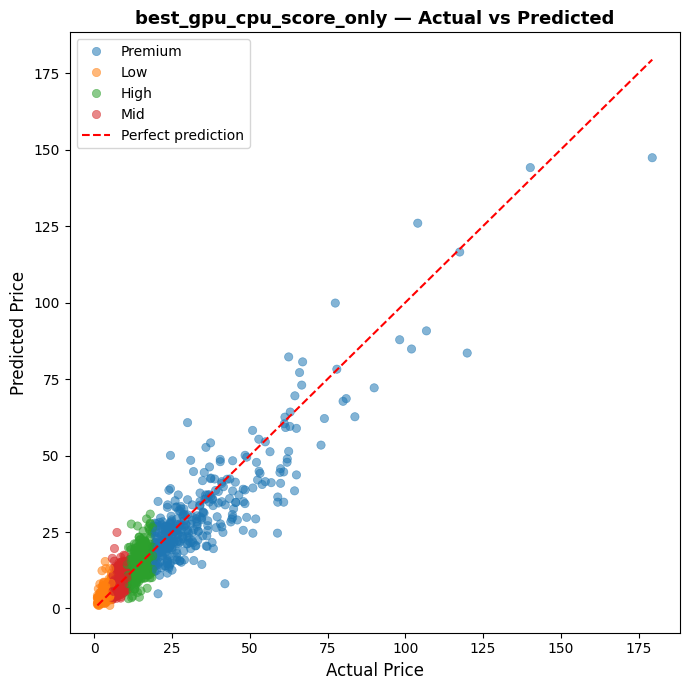

        experiment_name    mae   rmse     r2  mape_pct
best_gpu_cpu_score_only 3.3792 5.4711 0.8752   28.6420


In [362]:
BEST_FEATURES_SO_FAR = [
    "gpu_cpu_score"
]

X_best_gpu_cpu = make_feature_set(
    X_baseline,
    X_next_all,
    BEST_FEATURES_SO_FAR,
)

print("Added features:", [c for c in X_best_gpu_cpu.columns if c not in X_baseline.columns])
print("X_best_gpu_cpu shape:", X_best_gpu_cpu.shape)

result_best_gpu_cpu, metrics_best_gpu_cpu = run_experiment(
    X=X_best_gpu_cpu,
    y_log=y_log,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="best_gpu_cpu_score_only",
    plot=True,
)

### Observation

Kết quả của `best_gpu_cpu_score_only` cho thấy feature `gpu_cpu_score` là candidate tốt nhất hiện tại. Mô hình đạt MAE = 3.3730, RMSE = 5.4476, R² = 0.8763 và MAPE = 28.3898%. So với baseline, tất cả các metric chính đều được cải thiện, cho thấy interaction giữa GPU tier và CPU tier bổ sung tín hiệu hữu ích cho mô hình.

Biểu đồ Actual vs Predicted cho thấy phần lớn điểm dự đoán nằm tương đối gần đường perfect prediction, đặc biệt ở các phân khúc giá thấp và trung bình. Điều này cho thấy mô hình đang học khá tốt quan hệ giá trong vùng dữ liệu phổ biến.

Tuy nhiên, ở nhóm `Premium`, các điểm vẫn phân tán rộng hơn đáng kể. Một số laptop có giá thực tế rất cao vẫn bị dự đoán thấp hơn, cho thấy hiện tượng underprediction ở phân khúc cao cấp chưa được xử lý hoàn toàn. Đây là pattern đã xuất hiện trong high-error audit trước đó.

Feature `gpu_cpu_score` giúp cải thiện hiệu năng tổng thể vì laptop cao cấp, gaming hoặc workstation thường được định giá dựa trên tổ hợp CPU mạnh và GPU mạnh. Tuy nhiên, chỉ riêng CPU-GPU interaction chưa đủ để giải thích toàn bộ chênh lệch giá ở nhóm premium, vì giá còn phụ thuộc vào model family, brand, tình trạng máy, bảo hành, đời máy và các yếu tố build quality.

Từ kết quả hiện tại, `gpu_cpu_score` nên được giữ lại trong candidate feature set. Bước tiếp theo nên tập trung đánh giá lỗi riêng theo phân khúc, đặc biệt là `Premium`, để kiểm tra liệu feature này có thật sự giảm underprediction ở nhóm giá cao hay chỉ cải thiện metric tổng thể.